<a href="https://colab.research.google.com/github/uavinash15/DataScience-/blob/main/ML_Projects/Product_Recommendation_system/Product_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  # **Product Recommendation System**

# Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

Loading the dataset into a DataFrame

In [ ]:
rating_df=pd.read_csv('rating_short.csv')

In [ ]:
type(rating_df)

pandas.core.frame.DataFrame

 Displaying First Few Records of the DataFrame

In [ ]:
rating_df.head()

,userid,productid,rating,date
0,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0,1199750400
1,ALDXDYEGKB27G,B002L6HE9G,4.0,1331337600
2,A15LOGO6NBSI6B,B007MXGG5Q,5.0,1358640000
3,A23LX12CA3G4FG,B008HOEDYU,1.0,1385337600
4,A3TV7QFYXAG130,B0069R7TAM,5.0,1402963200


 Finding Summary of the DataFrame

In [ ]:
list(rating_df.columns)

['userid', 'productid', 'rating', 'date']

In [ ]:
rating_df.shape

(78245, 4)

In [ ]:
rating_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78245 entries, 0 to 78244
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   userid     78245 non-null  object 
 1   productid  78245 non-null  object 
 2   rating     78245 non-null  float64
 3   date       78245 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 2.4+ MB


 Value Counts


In [ ]:
rating_df.userid.value_counts()

,count
userid,
A3LGT6UZL99IW1,8
A1ODOGXEYECQQ8,8
ARBKYIVNYWK3C,7
ADLVFFE4VBT8,7
A2AY4YUOX2N1BQ,6
...,...
A1IJK68DNYRFA,1
A1OASIEEUPNVXY,1
AR656PUXSSKOY,1


In [ ]:
rating_df.rating.value_counts()

,count
rating,
5.0,43360
4.0,14878
1.0,9128
3.0,6287
2.0,4592


In [ ]:
rating_df.date.value_counts()

,count
date,
1389052800,201
1388707200,187
1380672000,173
1404691200,149
1388620800,145
...,...
1143676800,1
1107561600,1
1072310400,1


 Removing a Column Date

In [ ]:
rating_df.drop('date',axis=1,inplace=True)

In [ ]:
rating_df.head()

,userid,productid,rating
0,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0
1,ALDXDYEGKB27G,B002L6HE9G,4.0
2,A15LOGO6NBSI6B,B007MXGG5Q,5.0
3,A23LX12CA3G4FG,B008HOEDYU,1.0
4,A3TV7QFYXAG130,B0069R7TAM,5.0


Handling missing values

In [ ]:
rating_df.isnull().sum()

,0
userid,0
productid,0
rating,0


there are no null values in userid, prodcut id, rating

Identifying and correcting any inconsistencies in data types

In [ ]:
rating_df.dtypes

,0
userid,object
productid,object
rating,float64


There are no inconsistencies in data types

Detecting and treating outliers

boxplot

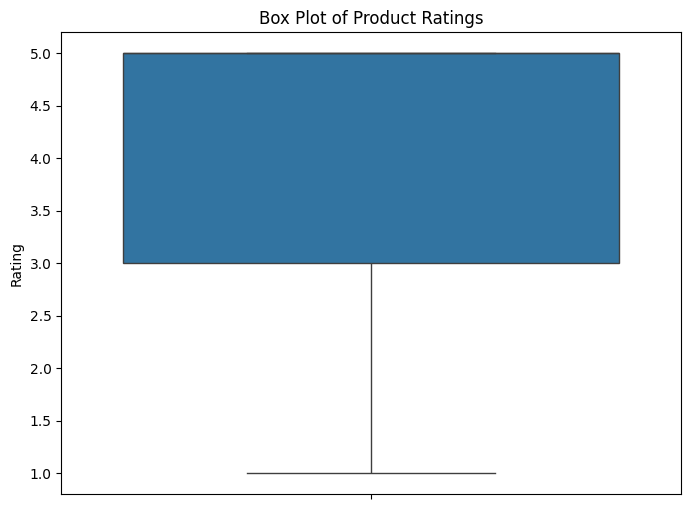

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=rating_df['rating'])
plt.title('Box Plot of Product Ratings')
plt.ylabel('Rating')
plt.show()

from above picture it's clear that there are no outliers

Statistical Summary

In [ ]:
print('mean of rating : ',rating_df['rating'].mean())

mean of rating :  4.0064540865231


In [ ]:
print('Median of rating: ',rating_df['rating'].median())

Median of rating:  5.0


In [ ]:
print('mode of rating: ',rating_df['rating'].mode())

mode of rating:  0    5.0
Name: rating, dtype: float64


In [ ]:
print('standard deviation of rating: ',rating_df['rating'].std())

standard deviation of rating:  1.3853420505722094


In [ ]:
Q1 = rating_df['rating'].quantile(0.25)
Q3 = rating_df['rating'].quantile(0.75)

In [ ]:
print('Q1 (25th percentile) of rating: ',Q1)

Q1 (25th percentile) of rating:  3.0


In [ ]:
print('Q3 (75th percentile of rating): ',Q3)

Q3 (75th percentile of rating):  5.0


In [ ]:
IQR = Q3 - Q1
print('IQR (Interquartile Range) of rating: ',IQR)

IQR (Interquartile Range) of rating:  2.0


In [ ]:
rating_df.describe()

,rating
count,78245.000000
mean,4.006454
std,1.385342
min,1.000000
25%,3.000000
50%,5.000000
75%,5.000000
max,5.000000


Data Visualization:

Histogram

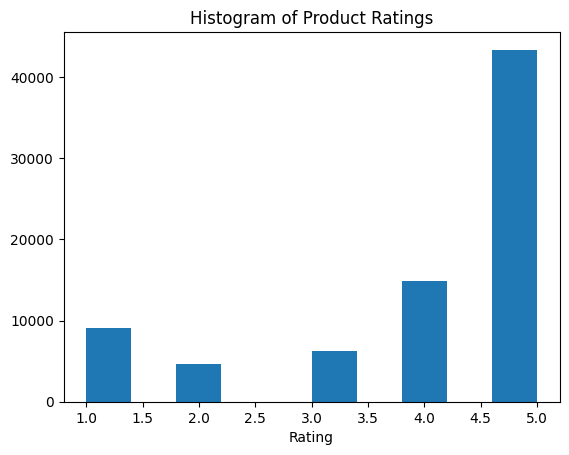

In [ ]:
plt.hist(rating_df['rating'], bins=10)
plt.title('Histogram of Product Ratings')
plt.xlabel('Rating')
plt.show()

Distribution or Density Plot

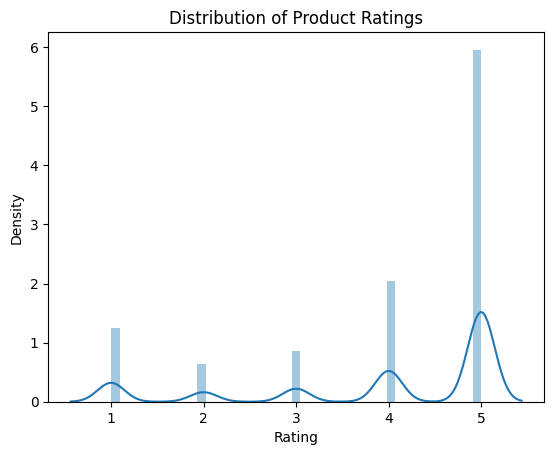

In [ ]:
sns.distplot(rating_df['rating'])
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.show()

Bar Plot

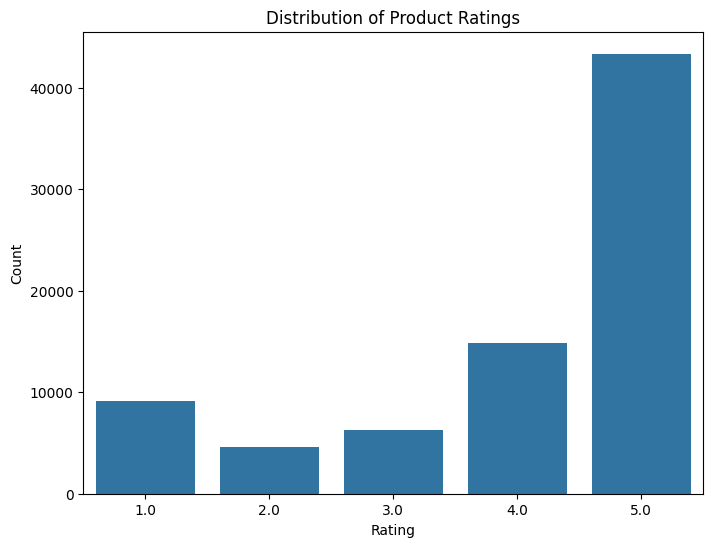

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='rating', data=rating_df)
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

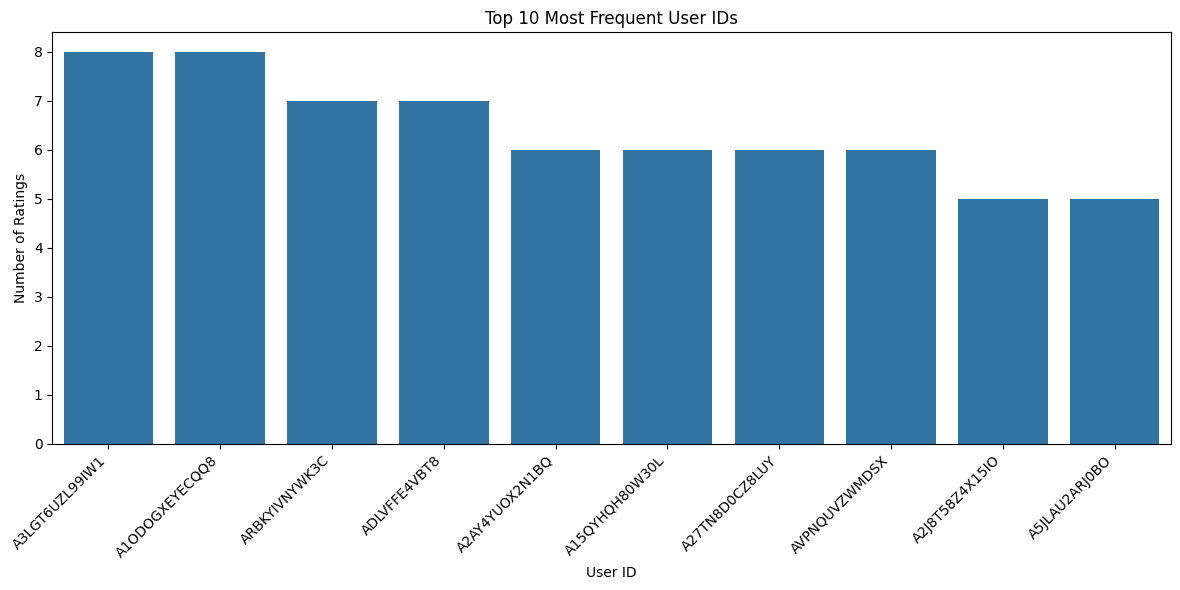

In [ ]:
plt.figure(figsize=(12, 6))
top_10_users = rating_df['userid'].value_counts().nlargest(10).index
sns.countplot(x='userid', data=rating_df[rating_df['userid'].isin(top_10_users)], order=top_10_users)
plt.title('Top 10 Most Frequent User IDs')
plt.xlabel('User ID')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

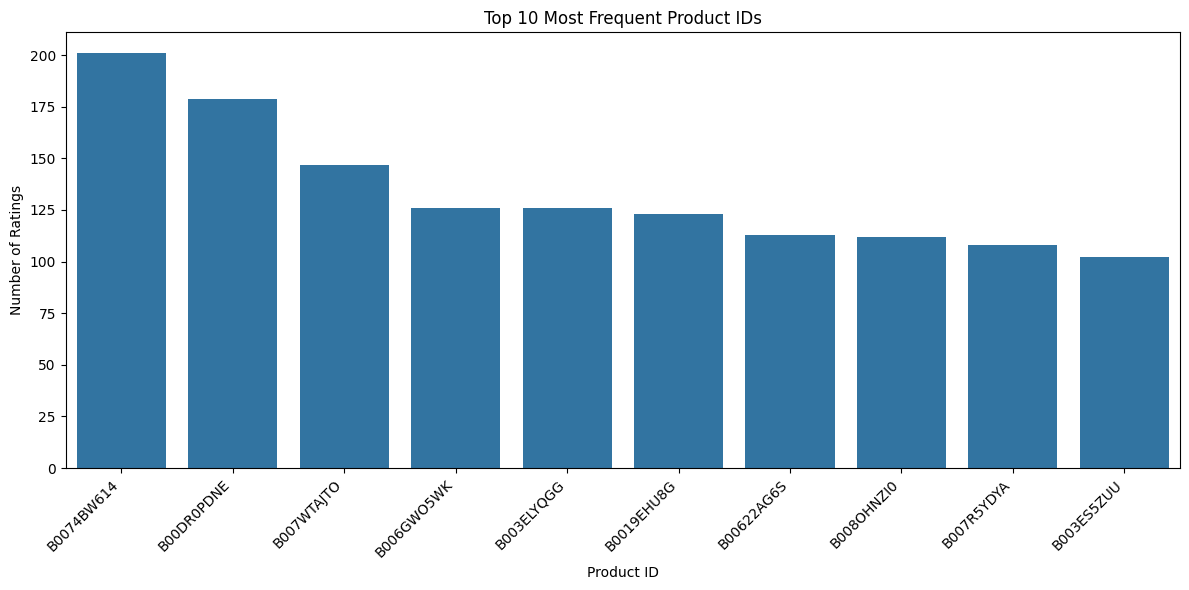

In [ ]:
plt.figure(figsize=(12, 6))
top_10_products = rating_df['productid'].value_counts().nlargest(10).index
sns.countplot(x='productid', data=rating_df[rating_df['productid'].isin(top_10_products)], order=top_10_products)
plt.title('Top 10 Most Frequent Product IDs')
plt.xlabel('Product ID')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Pie charts

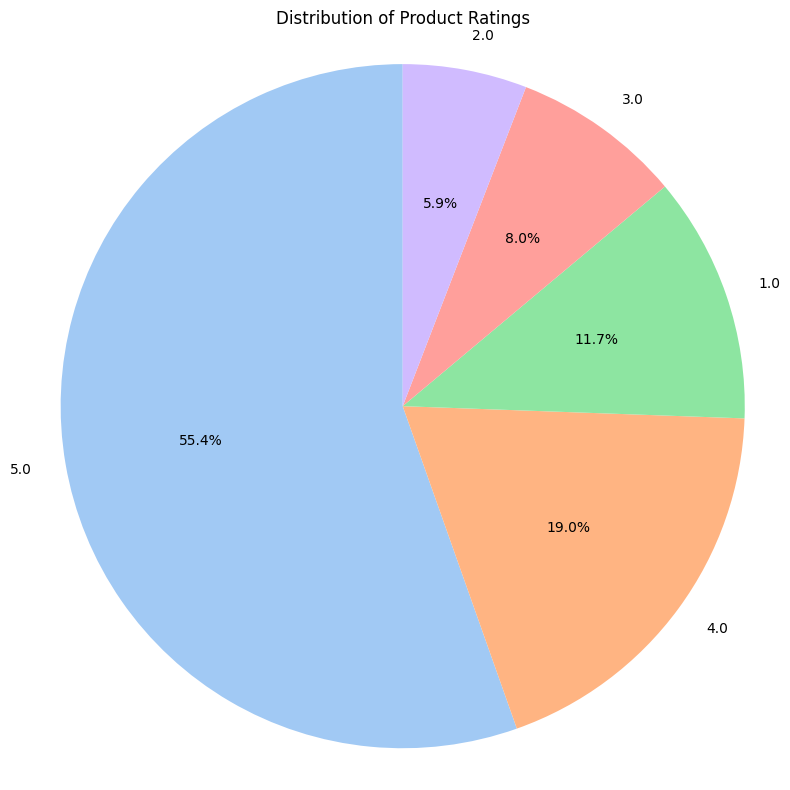

In [ ]:
rating_counts = rating_df['rating'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribution of Product Ratings')
plt.axis('equal')
plt.tight_layout()
plt.show()

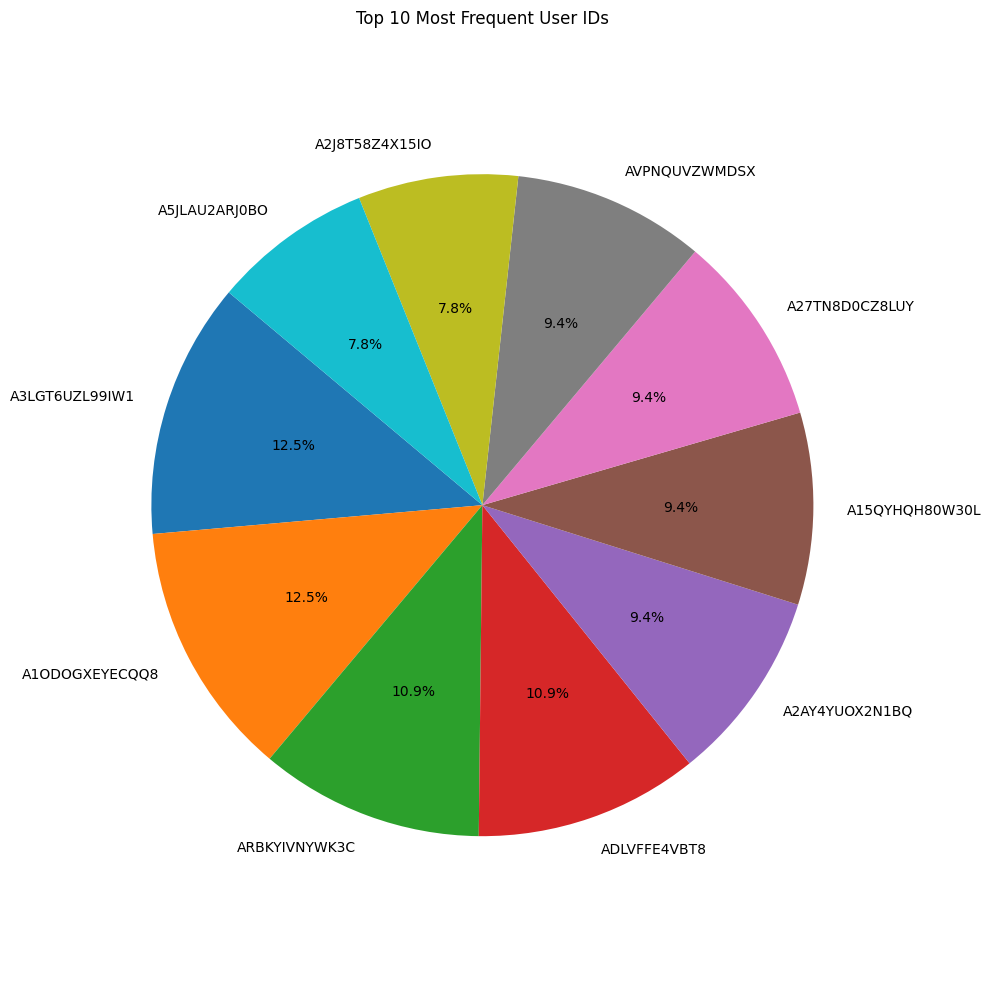

In [ ]:
plt.figure(figsize=(10, 10))
top_10_users_counts = rating_df['userid'].value_counts().nlargest(10)
plt.pie(top_10_users_counts, labels=top_10_users_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Most Frequent User IDs')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

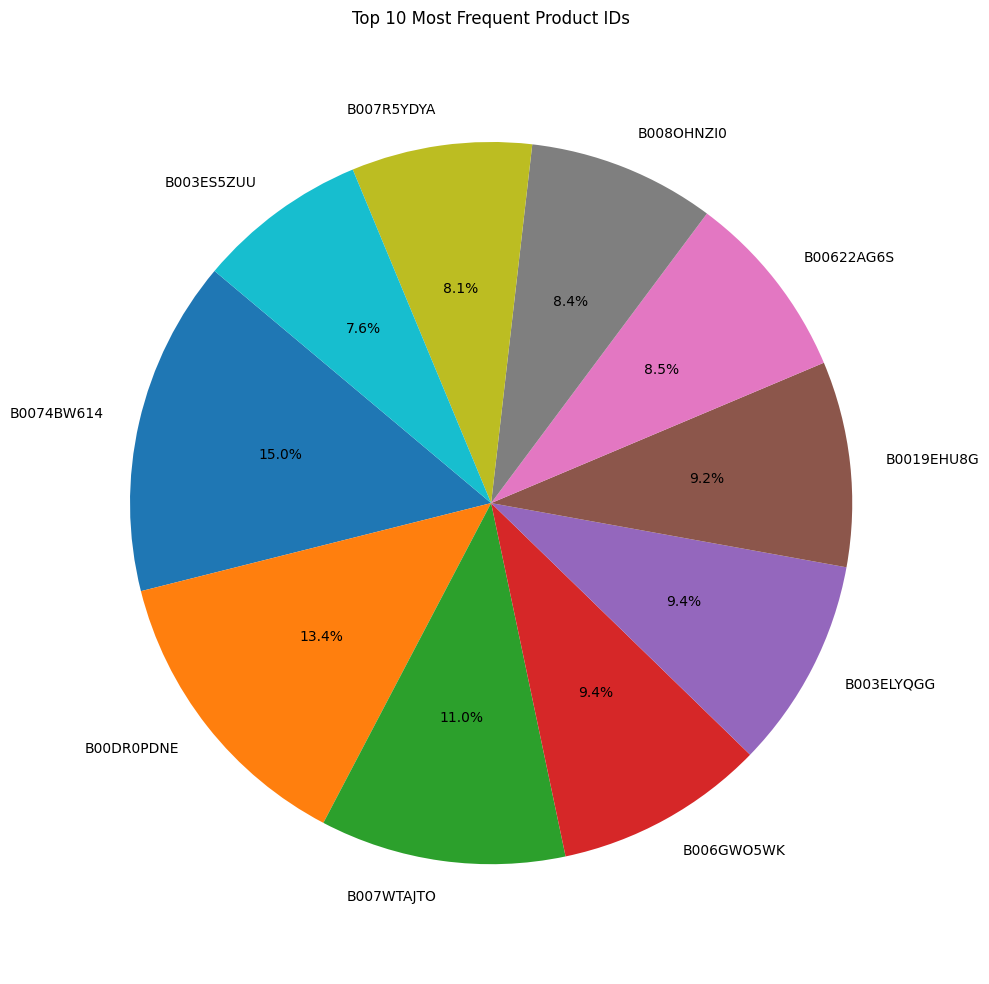

In [ ]:
plt.figure(figsize=(10, 10))
top_10_products_counts = rating_df['productid'].value_counts().nlargest(10)
plt.pie(top_10_products_counts, labels=top_10_products_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Most Frequent Product IDs')
plt.axis('equal')
plt.tight_layout()
plt.show()

scatter plots

In [ ]:
product_stats = rating_df.groupby('productid')['rating'].agg(['count', 'mean']).reset_index()
product_stats

,productid,count,mean
0,0594481813,1,5.000000
1,0972683275,7,4.428571
2,0983947600,1,5.000000
3,1400501466,1,5.000000
4,1400501776,1,5.000000
...,...,...,...
40223,B00KYMCJF8,1,5.000000
40224,B00KZ40HT0,1,5.000000
40225,B00L1LXOWS,1,5.000000
40226,B00L26IGP2,1,1.000000


In [ ]:
product_stats.columns = ['productid', 'num_ratings', 'avg_rating']
product_stats

,productid,num_ratings,avg_rating
0,0594481813,1,5.000000
1,0972683275,7,4.428571
2,0983947600,1,5.000000
3,1400501466,1,5.000000
4,1400501776,1,5.000000
...,...,...,...
40223,B00KYMCJF8,1,5.000000
40224,B00KZ40HT0,1,5.000000
40225,B00L1LXOWS,1,5.000000
40226,B00L26IGP2,1,1.000000


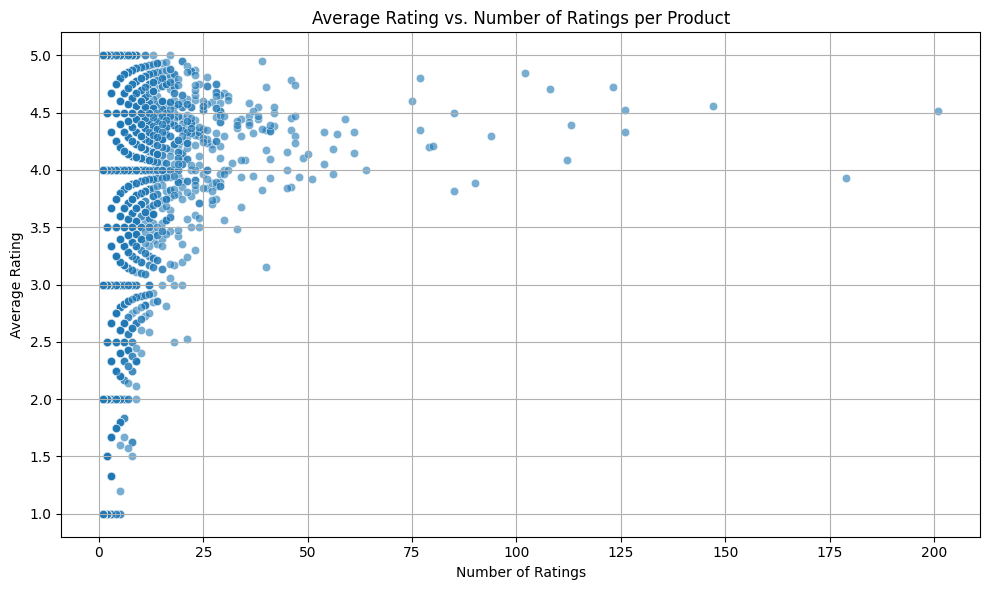

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='num_ratings', y='avg_rating', data=product_stats, alpha=0.6)
plt.title('Average Rating vs. Number of Ratings per Product')
plt.xlabel('Number of Ratings')
plt.ylabel('Average Rating')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
user_stats = rating_df.groupby('userid')['rating'].agg(['count', 'mean']).reset_index()
user_stats

,userid,count,mean
0,A000063614T1OE0BUSKUT,1,5.0
1,A0009478CBXKUCALUC7U,1,5.0
2,A00101847G3FJTWYGNQA,1,5.0
3,A00229361XSNMXZ0NHCP0,1,3.0
4,A00261423251DFHHYVST9,1,5.0
...,...,...,...
76425,AZZXSM5W248P8,1,4.0
76426,AZZXYB7CMAC6Z,1,5.0
76427,AZZY7T62AF17E,1,5.0
76428,AZZYW4YOE1B6E,1,5.0


In [ ]:
user_stats.columns = ['userid', 'num_ratings', 'avg_rating']
user_stats

,userid,num_ratings,avg_rating
0,A000063614T1OE0BUSKUT,1,5.0
1,A0009478CBXKUCALUC7U,1,5.0
2,A00101847G3FJTWYGNQA,1,5.0
3,A00229361XSNMXZ0NHCP0,1,3.0
4,A00261423251DFHHYVST9,1,5.0
...,...,...,...
76425,AZZXSM5W248P8,1,4.0
76426,AZZXYB7CMAC6Z,1,5.0
76427,AZZY7T62AF17E,1,5.0
76428,AZZYW4YOE1B6E,1,5.0


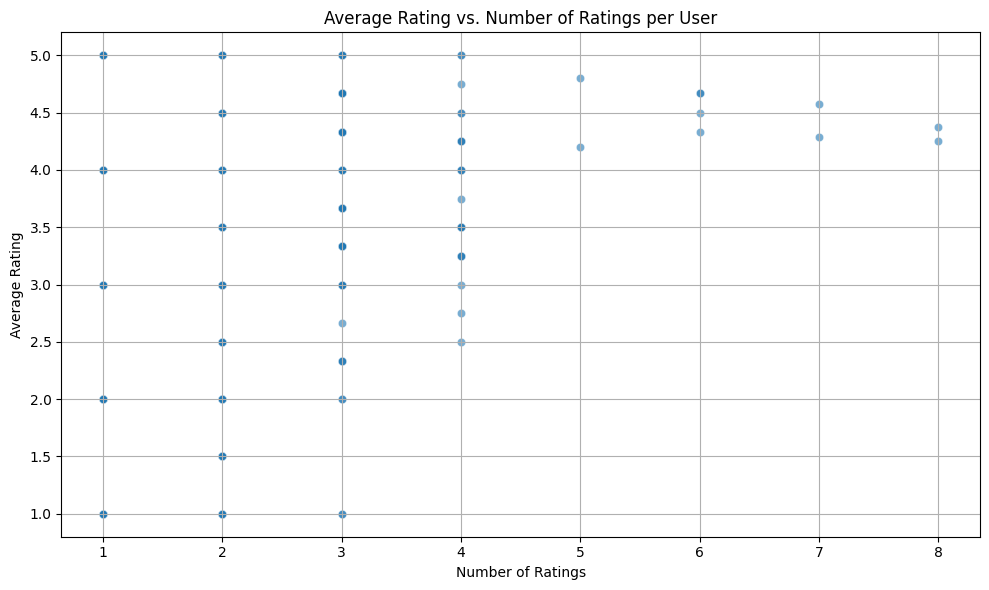

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='num_ratings', y='avg_rating', data=user_stats, alpha=0.6)
plt.title('Average Rating vs. Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Average Rating')
plt.grid(True)
plt.tight_layout()
plt.show()

correlation heatmaps

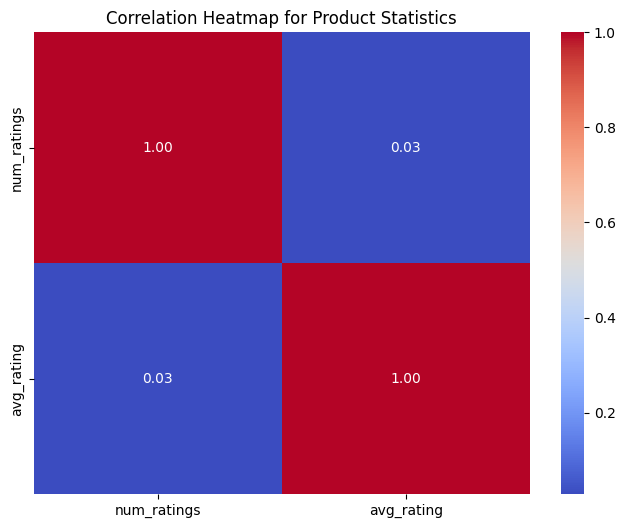

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(product_stats[['num_ratings', 'avg_rating']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for Product Statistics')
plt.show()


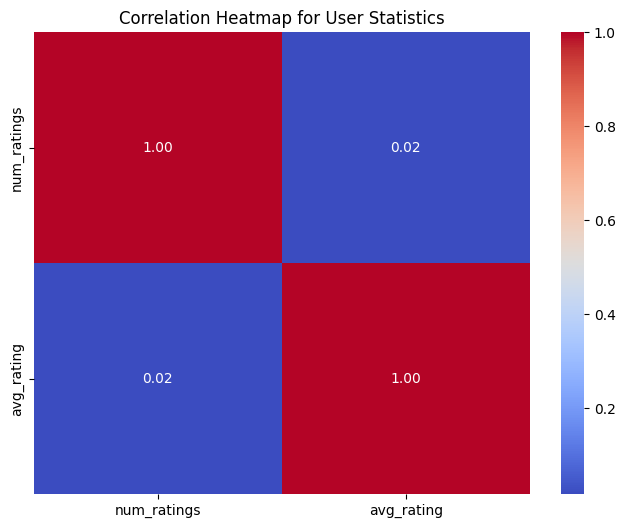

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(user_stats[['num_ratings', 'avg_rating']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for User Statistics')
plt.show()

Pairplots

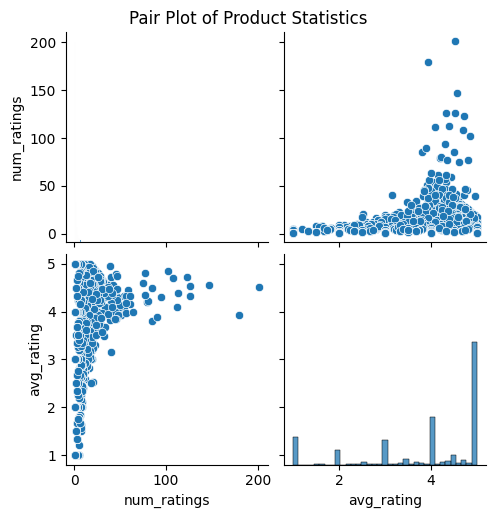

In [ ]:
sns.pairplot(product_stats[['num_ratings', 'avg_rating']])
plt.suptitle('Pair Plot of Product Statistics', y=1.02)
plt.show()

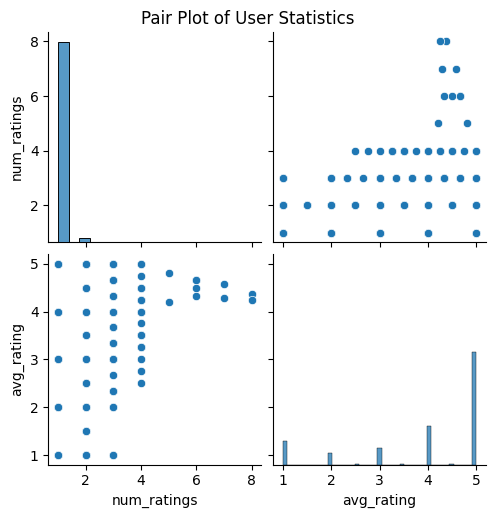

In [ ]:
sns.pairplot(user_stats[['num_ratings', 'avg_rating']])
plt.suptitle('Pair Plot of User Statistics', y=1.02)
plt.show()

Violing Plots

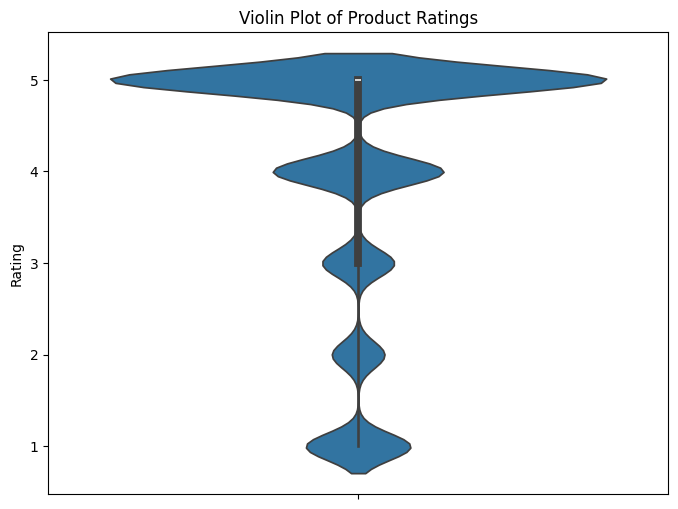

In [ ]:
plt.figure(figsize=(8, 6))
sns.violinplot(y=rating_df['rating'])
plt.title('Violin Plot of Product Ratings')
plt.ylabel('Rating')
plt.show()

## Pattern Recognition and Insights

**Correlation Analysis**

1.  **Product Statistics (Number of Ratings vs. Average Rating):** The correlation coefficient between the number of ratings (`num_ratings`) and the average rating (`avg_rating`) for products is approximately **0.03**. This indicates a very weak positive linear correlation.
    *   **Implication:** This suggests that there is almost no linear relationship between how many ratings a product receives and its average rating. Products with more ratings are not significantly more likely to have higher average ratings, and vice versa. Other factors, independent of rating volume, likely play a more substantial role in determining a product's average score.

2.  **User Statistics (Number of Ratings vs. Average Rating):** The correlation coefficient between the number of ratings (`num_ratings`) and the average rating (`avg_rating`) for users is approximately **0.02**. This also indicates a very weak positive linear correlation, essentially close to zero.
    *   **Implication:** This implies that there is practically no linear relationship between how many products a user rates and their average rating across those products. Users who provide many ratings do not consistently rate products higher or lower on average than users who provide fewer ratings. A user's rating behavior, in terms of their average score, appears to be independent of their overall activity level.

**Summary of Implications:**

The very low correlation coefficients for both product and user statistics suggest that the volume of ratings (either for a product or by a user) does not strongly predict the average rating. This indicates that other, more complex factors are at play in shaping both product performance and user rating habits. Therefore, simply looking at the number of ratings might not be a good indicator for predicting average ratings in this dataset.

**Temporal Data:**

The 'date' column was dropped earlier in the analysis, so it is not possible to identify any trends or patterns over time using this dataset.

Applying scaling techniques to numerical features:

Applying scaling techniques to numerical features is generally recommended before training machine learning models, especially those sensitive to feature scales (e.g., K-Nearest Neighbors, Support Vector Machines, Neural Networks). Scaling helps prevent features with larger values from disproportionately influencing the model's objective function.

In this `rating_df` dataset:

1.  **`userid` and `productid`**: These are categorical identifiers. Scaling techniques are not applicable to these columns directly. If these were to be used as features in a model, they would typically undergo encoding (e.g., one-hot encoding, label encoding, or embedded in an embedding layer for deep learning models).

2.  **`rating`**: This is a numerical feature, but it's already on a fixed, small scale (1 to 5). For features with such a constrained and small range, standard scaling (like StandardScaler or MinMaxScaler) might not be strictly necessary for all models. Some models can work effectively with these raw values. However, for certain algorithms (e.g., K-Means clustering or PCA where distance metrics are important), or deep learning models, scaling to a range like `[0, 1]` or standardizing to a mean of 0 and standard deviation of 1 (`z-score normalization`) could still be beneficial.

**Conclusion:**

Given that the `rating` column is already on a small, defined scale, explicit scaling might not be as critical as it would be for features with very large or disparate ranges. However, it's a good practice to consider it during the feature engineering phase, especially once you've decided on the specific machine learning model you intend to use. For the current exploratory analysis, it's not a prerequisite.

**Feature Engineering:**

Merging product statistics into a new DataFrame

In [ ]:
rating_features_df = pd.merge(rating_df,
                              product_stats.rename(columns={'num_ratings': 'product_num_ratings', 'avg_rating': 'product_avg_rating'}),
                              on='productid',
                              how='left')
rating_features_df.head()

,userid,productid,rating,product_num_ratings,product_avg_rating
0,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0,2,4.500000
1,ALDXDYEGKB27G,B002L6HE9G,4.0,7,2.714286
2,A15LOGO6NBSI6B,B007MXGG5Q,5.0,4,4.750000
3,A23LX12CA3G4FG,B008HOEDYU,1.0,2,1.500000
4,A3TV7QFYXAG130,B0069R7TAM,5.0,1,5.000000


Merging user statistics into the new DataFrame

In [ ]:
rating_features_df = pd.merge(rating_features_df,
                              user_stats.rename(columns={'num_ratings': 'user_num_ratings', 'avg_rating': 'user_avg_rating'}),
                              on='userid',
                              how='left')
rating_features_df.head()

,userid,productid,rating,product_num_ratings,product_avg_rating,user_num_ratings,user_avg_rating
0,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0,2,4.500000,1,5.0
1,ALDXDYEGKB27G,B002L6HE9G,4.0,7,2.714286,1,4.0
2,A15LOGO6NBSI6B,B007MXGG5Q,5.0,4,4.750000,1,5.0
3,A23LX12CA3G4FG,B008HOEDYU,1.0,2,1.500000,1,1.0
4,A3TV7QFYXAG130,B0069R7TAM,5.0,1,5.000000,2,5.0


Creating 'rating_deviation_from_product_avg column'

In [ ]:
rating_features_df['rating_deviation_from_product_avg'] = rating_features_df['rating'] - rating_features_df['product_avg_rating']
rating_features_df.head()

,userid,productid,rating,product_num_ratings,product_avg_rating,user_num_ratings,user_avg_rating,rating_deviation_from_product_avg
0,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0,2,4.500000,1,5.0,0.500000
1,ALDXDYEGKB27G,B002L6HE9G,4.0,7,2.714286,1,4.0,1.285714
2,A15LOGO6NBSI6B,B007MXGG5Q,5.0,4,4.750000,1,5.0,0.250000
3,A23LX12CA3G4FG,B008HOEDYU,1.0,2,1.500000,1,1.0,-0.500000
4,A3TV7QFYXAG130,B0069R7TAM,5.0,1,5.000000,2,5.0,0.000000


Creating 'rating_deviation_from_user_avg column'

In [ ]:
rating_features_df['rating_deviation_from_user_avg'] = rating_features_df['rating'] - rating_features_df['user_avg_rating']
rating_features_df.head()

,userid,productid,rating,product_num_ratings,product_avg_rating,user_num_ratings,user_avg_rating,rating_deviation_from_product_avg,rating_deviation_from_user_avg
0,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0,2,4.500000,1,5.0,0.500000,0.0
1,ALDXDYEGKB27G,B002L6HE9G,4.0,7,2.714286,1,4.0,1.285714,0.0
2,A15LOGO6NBSI6B,B007MXGG5Q,5.0,4,4.750000,1,5.0,0.250000,0.0
3,A23LX12CA3G4FG,B008HOEDYU,1.0,2,1.500000,1,1.0,-0.500000,0.0
4,A3TV7QFYXAG130,B0069R7TAM,5.0,1,5.000000,2,5.0,0.000000,0.0


In [ ]:
rating_features_df[['userid', 'productid', 'rating',
                         'product_avg_rating', 'rating_deviation_from_product_avg',
                         'user_avg_rating', 'rating_deviation_from_user_avg']].head()

,userid,productid,rating,product_avg_rating,rating_deviation_from_product_avg,user_avg_rating,rating_deviation_from_user_avg
0,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0,4.500000,0.500000,5.0,0.0
1,ALDXDYEGKB27G,B002L6HE9G,4.0,2.714286,1.285714,4.0,0.0
2,A15LOGO6NBSI6B,B007MXGG5Q,5.0,4.750000,0.250000,5.0,0.0
3,A23LX12CA3G4FG,B008HOEDYU,1.0,1.500000,-0.500000,1.0,0.0
4,A3TV7QFYXAG130,B0069R7TAM,5.0,5.000000,0.000000,5.0,0.0


## Rationale Behind New Features

**1. Rating Deviation from Product Average (`rating_deviation_from_product_avg`)**

*   **Rationale:** This feature is calculated as `rating - product_avg_rating`. It quantifies how a specific user's rating for a product differs from the average rating that product has received from all users. A positive deviation indicates the user rated the product higher than its average, while a negative deviation means they rated it lower. This can be beneficial for the model as it helps to:
    *   **Identify Niche Preferences/Dislikes:** Highlight if a user has an unusually strong positive or negative opinion about a product compared to the general sentiment.
    *   **Capture User-Product Interaction Uniqueness:** It goes beyond the absolute rating to show the relative enthusiasm or disappointment of a user for a particular item.

**2. Rating Deviation from User Average (`rating_deviation_from_user_avg`)**

*   **Rationale:** This feature is calculated as `rating - user_avg_rating`. It represents the difference between a user's given rating for a product and their own average rating across all products they have rated. This feature is valuable because it:
    *   **Normalizes User Rating Behavior:** Accounts for individual user biases in rating (e.g., some users consistently give high ratings, while others are more critical). A '3' from a user who typically rates everything '2' is more significant than a '3' from a user who rates everything '5'.
    *   **Makes Ratings More Comparable:** By removing the user's personal baseline, it makes the relative quality assessment more consistent across different users, which can lead to better predictions of how a user *truly* feels about a product, independent of their general rating scale.

In [ ]:
rating_features_df['product_num_ratings_log'] = np.log1p(rating_features_df['product_num_ratings'])
rating_features_df['user_num_ratings_log'] = np.log1p(rating_features_df['user_num_ratings'])
rating_features_df.head()

,userid,productid,rating,product_num_ratings,product_avg_rating,user_num_ratings,user_avg_rating,rating_deviation_from_product_avg,rating_deviation_from_user_avg,product_num_ratings_log,user_num_ratings_log
0,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0,2,4.500000,1,5.0,0.500000,0.0,1.098612,0.693147
1,ALDXDYEGKB27G,B002L6HE9G,4.0,7,2.714286,1,4.0,1.285714,0.0,2.079442,0.693147
2,A15LOGO6NBSI6B,B007MXGG5Q,5.0,4,4.750000,1,5.0,0.250000,0.0,1.609438,0.693147
3,A23LX12CA3G4FG,B008HOEDYU,1.0,2,1.500000,1,1.0,-0.500000,0.0,1.098612,0.693147
4,A3TV7QFYXAG130,B0069R7TAM,5.0,1,5.000000,2,5.0,0.000000,0.0,0.693147,1.098612


In [ ]:
rating_features_df[['userid', 'productid', 'rating', 'product_num_ratings', 'product_num_ratings_log', 'user_num_ratings', 'user_num_ratings_log']].head()

,userid,productid,rating,product_num_ratings,product_num_ratings_log,user_num_ratings,user_num_ratings_log
0,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0,2,1.098612,1,0.693147
1,ALDXDYEGKB27G,B002L6HE9G,4.0,7,2.079442,1,0.693147
2,A15LOGO6NBSI6B,B007MXGG5Q,5.0,4,1.609438,1,0.693147
3,A23LX12CA3G4FG,B008HOEDYU,1.0,2,1.098612,1,0.693147
4,A3TV7QFYXAG130,B0069R7TAM,5.0,1,0.693147,2,1.098612


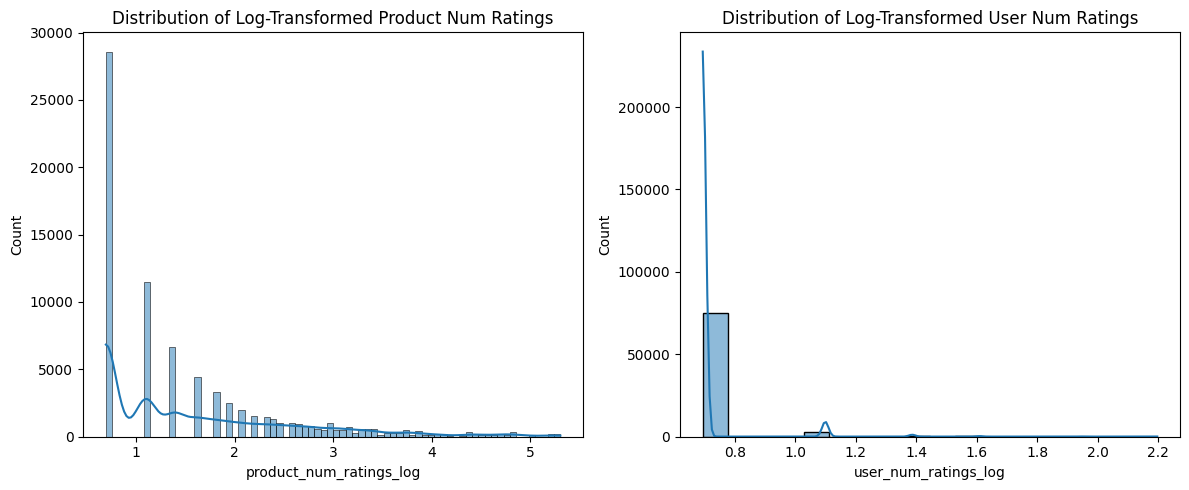

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(rating_features_df['product_num_ratings_log'], kde=True)
plt.title('Distribution of Log-Transformed Product Num Ratings')

plt.subplot(1, 2, 2)
sns.histplot(rating_features_df['user_num_ratings_log'], kde=True)
plt.title('Distribution of Log-Transformed User Num Ratings')

plt.tight_layout()
plt.show()

**Justification for Log Transformation on 'product_num_ratings' and 'user_num_ratings':**
1. Addressing Skewness: These count-based features often have a highly skewed distribution.
Log transformation helps to reduce this skewness, making the distribution more symmetrical
and closer to a normal distribution, which is beneficial for many machine learning models.
2. Stabilizing Variance: It can help stabilize the variance of the data, leading to more
    consistent data spread across different value ranges.
 3. Mitigating Outlier Impact: By compressing larger values, the log transformation can
    reduce the influence of extreme outliers, making the model less sensitive to them.
 4. Improving Model Performance: Many algorithms assume or perform better with normally
    distributed features. Transforming skewed data can lead to improved model performance
    and more reliable statistical inferences.
 5. Using `np.log1p`: The `np.log1p(x)` function computes `log(1+x)`. This is particularly
    useful here because counts can be zero. Adding 1 before taking the logarithm ensures
    that the operation is always defined (logarithm of zero is undefined) and handles
    zero values gracefully, preventing errors and allowing a smooth transformation for all values.

**Feature Selection:**

In [ ]:
from sklearn.ensemble import IsolationForest

selcting Features for outlier detection

In [ ]:
features_for_outliers = ['rating', 'product_avg_rating', 'product_num_ratings_log', 'user_avg_rating', 'user_num_ratings_log']
X = rating_features_df[features_for_outliers]
X.head()

,rating,product_avg_rating,product_num_ratings_log,user_avg_rating,user_num_ratings_log
0,5.0,4.500000,1.098612,5.0,0.693147
1,4.0,2.714286,2.079442,4.0,0.693147
2,5.0,4.750000,1.609438,5.0,0.693147
3,1.0,1.500000,1.098612,1.0,0.693147
4,5.0,5.000000,0.693147,5.0,1.098612


Initializing Isolation Forest

In [ ]:
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42, n_jobs=-1) #n_jobs=  -1  is used for instructing to use cpus for fast performance
iso_forest

IsolationForest(contamination=0.01, n_jobs=-1, random_state=42)

A contamination of 0.01 means we expect 1% of the data to be outliers.

Fitting the model and predicting outliers

In [ ]:
outlier_predictions = iso_forest.fit_predict(X)
outlier_predictions

array([1, 1, 1, ..., 1, 1, 1])

(1 for inliers, -1 for outliers)

Adding outlier predictions to the DataFrame

In [ ]:
rating_features_df['outlier'] = outlier_predictions
rating_features_df.head()

,userid,productid,rating,product_num_ratings,product_avg_rating,user_num_ratings,user_avg_rating,rating_deviation_from_product_avg,rating_deviation_from_user_avg,product_num_ratings_log,user_num_ratings_log,outlier
0,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0,2,4.500000,1,5.0,0.500000,0.0,1.098612,0.693147,1
1,ALDXDYEGKB27G,B002L6HE9G,4.0,7,2.714286,1,4.0,1.285714,0.0,2.079442,0.693147,1
2,A15LOGO6NBSI6B,B007MXGG5Q,5.0,4,4.750000,1,5.0,0.250000,0.0,1.609438,0.693147,1
3,A23LX12CA3G4FG,B008HOEDYU,1.0,2,1.500000,1,1.0,-0.500000,0.0,1.098612,0.693147,1
4,A3TV7QFYXAG130,B0069R7TAM,5.0,1,5.000000,2,5.0,0.000000,0.0,0.693147,1.098612,1


outliers

In [ ]:
outliers = rating_features_df[rating_features_df['outlier'] == -1]
outliers.head()

,userid,productid,rating,product_num_ratings,product_avg_rating,user_num_ratings,user_avg_rating,rating_deviation_from_product_avg,rating_deviation_from_user_avg,product_num_ratings_log,user_num_ratings_log,outlier
6,A3N1G4PVX0XK0O,B0043GCBU4,3.0,2,4.000000,3,3.00,-1.000000,0.00,1.098612,1.386294,-1
29,A1J0VBLYKJGSJU,B003LR7ME6,1.0,85,4.494118,1,1.00,-3.494118,0.00,4.454347,0.693147,-1
159,AG1NSINZINJ99,B0074BW614,1.0,201,4.517413,1,1.00,-3.517413,0.00,5.308268,0.693147,-1
234,ASVLHEA1PVXP0,B001W0Y44K,2.0,1,2.000000,2,3.50,0.000000,-1.50,0.693147,1.098612,-1
352,AGVWTYW0ULXHT,B00IVPU59W,4.0,1,4.000000,4,3.25,0.000000,0.75,0.693147,1.609438,-1


Non outliers

In [ ]:
rating_features_df_cleaned = rating_features_df[rating_features_df['outlier'] == 1].copy()
rating_features_df_cleaned.head()

,userid,productid,rating,product_num_ratings,product_avg_rating,user_num_ratings,user_avg_rating,rating_deviation_from_product_avg,rating_deviation_from_user_avg,product_num_ratings_log,user_num_ratings_log,outlier
0,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0,2,4.500000,1,5.0,0.500000,0.0,1.098612,0.693147,1
1,ALDXDYEGKB27G,B002L6HE9G,4.0,7,2.714286,1,4.0,1.285714,0.0,2.079442,0.693147,1
2,A15LOGO6NBSI6B,B007MXGG5Q,5.0,4,4.750000,1,5.0,0.250000,0.0,1.609438,0.693147,1
3,A23LX12CA3G4FG,B008HOEDYU,1.0,2,1.500000,1,1.0,-0.500000,0.0,1.098612,0.693147,1
4,A3TV7QFYXAG130,B0069R7TAM,5.0,1,5.000000,2,5.0,0.000000,0.0,0.693147,1.098612,1


In [ ]:
num_outliers = outliers.shape[0]
print(f"Total number of outliers detected: {num_outliers}")
print(f"Original DataFrame shape: {rating_features_df.shape}")
print(f"Cleaned DataFrame shape (after outlier removal): {rating_features_df_cleaned.shape}")
print(f"Percentage of outliers removed: {(num_outliers / rating_features_df.shape[0] * 100):.2f}%")


Total number of outliers detected: 783
Original DataFrame shape: (78245, 12)
Cleaned DataFrame shape (after outlier removal): (77462, 12)
Percentage of outliers removed: 1.00%


Dropping the temporary 'outlier' column from the cleaned DataFrame

In [ ]:
rating_features_df_cleaned = rating_features_df_cleaned.drop(columns=['outlier'])
rating_features_df_cleaned.head()

,userid,productid,rating,product_num_ratings,product_avg_rating,user_num_ratings,user_avg_rating,rating_deviation_from_product_avg,rating_deviation_from_user_avg,product_num_ratings_log,user_num_ratings_log
0,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0,2,4.500000,1,5.0,0.500000,0.0,1.098612,0.693147
1,ALDXDYEGKB27G,B002L6HE9G,4.0,7,2.714286,1,4.0,1.285714,0.0,2.079442,0.693147
2,A15LOGO6NBSI6B,B007MXGG5Q,5.0,4,4.750000,1,5.0,0.250000,0.0,1.609438,0.693147
3,A23LX12CA3G4FG,B008HOEDYU,1.0,2,1.500000,1,1.0,-0.500000,0.0,1.098612,0.693147
4,A3TV7QFYXAG130,B0069R7TAM,5.0,1,5.000000,2,5.0,0.000000,0.0,0.693147,1.098612


## Discussion on Outliers and Model Performance

**What are Outliers?**
Outliers are data points that significantly deviate from other observations. They can represent errors in data collection, rare events, or genuinely extreme values that are part of the underlying phenomenon.

**How Outliers Affect Model Performance:**

1.  **Bias in Model Parameters:** Many machine learning algorithms (especially linear models like Linear Regression or algorithms that rely on mean/variance calculations) are sensitive to outliers. A single extreme value can significantly shift the estimated parameters, leading to a biased model that doesn't accurately represent the majority of the data.
    *   **Example:** In a regression task, a few extremely high or low ratings could drastically skew the slope and intercept of the regression line.

2.  **Increased Variance:** Outliers can increase the variance of model predictions, making the model less stable and more prone to overfitting. The model might try to accommodate these unusual data points, leading to a more complex decision boundary that performs poorly on unseen, typical data.

3.  **Reduced Statistical Power:** The presence of outliers can reduce the statistical power of tests, making it harder to detect true relationships between variables.

4.  **Impact on Distance-Based Algorithms:** Algorithms like K-Nearest Neighbors (KNN) or K-Means clustering, which rely on distance metrics, are particularly susceptible to outliers. An outlier can pull cluster centroids towards itself or cause data points to be misclassified as neighbors.

5.  **Tree-Based Models (Less Affected but still):** Tree-based models (e.g., Decision Trees, Random Forests, Gradient Boosting Machines) are generally more robust to outliers because their splitting rules are based on impurity measures (like Gini impurity or entropy) rather than absolute values. However, very extreme outliers can still influence the splits at higher levels of the tree, especially if they are numerous.

**Why Remove Outliers with Isolation Forest?**
Isolation Forest works by randomly selecting a feature and then randomly selecting a split value between the maximum and minimum values of the selected feature. This process is repeated to create "isolation trees." Outliers are those data points that are easier to isolate (require fewer splits to be separated from the rest of the data). Removing these outliers can lead to:

*   **More Robust Models:** Models trained on cleaned data are less likely to be influenced by extreme values, resulting in more generalized and accurate predictions for typical data.
*   **Improved Efficiency:** Some algorithms might converge faster or require less computational power if they don't have to deal with noisy or extreme data points.
*   **Better Interpretation:** A model trained on data without strong outliers might offer clearer insights into the underlying relationships between features.

Sparse Matrix Representation - User Product Matrix

Since we have a large number of users and products, most users have rated
only a small fraction of products. Creating a full pivot table would require
~3 billion cells in RAM which crashes the session.
Instead, we directly build a CSR Sparse Matrix which only stores non-zero values.

In [ ]:
from scipy.sparse import csr_matrix

mapping userid and product id to integer indices

In [ ]:
userid_cat = rating_features_df_cleaned['userid'].astype('category')
userid_cat.head()

,userid
0,A1Z3YJF1S8Z1M3
1,ALDXDYEGKB27G
2,A15LOGO6NBSI6B
3,A23LX12CA3G4FG
4,A3TV7QFYXAG130


In [ ]:
userid_cat.shape

(77462,)

In [ ]:
productid_cat = rating_features_df_cleaned['productid'].astype('category')
productid_cat.head()

,productid
0,B000M9ISQ2
1,B002L6HE9G
2,B007MXGG5Q
3,B008HOEDYU
4,B0069R7TAM


In [ ]:
productid_cat.shape

(77462,)

In [ ]:
user_idx = userid_cat.cat.codes
user_idx.head()

,0
0,19722
1,68143
2,3267
3,22227
4,57026


In [ ]:
user_idx.shape

(77462,)

In [ ]:
product_idx = productid_cat.cat.codes
product_idx.head()

,0
0,6451
1,14254
2,29402
3,31390
4,27186


In [ ]:
product_idx.shape

(77462,)

building sparse matrix

In [ ]:
sparse_matrix = csr_matrix(
    (rating_features_df_cleaned['rating'], (user_idx, product_idx))
)
sparse_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 77462 stored elements and shape (76168, 39967)>

In [ ]:
print("Sparse matrix shape      :", sparse_matrix.shape)

Sparse matrix shape      : (76168, 39967)


In [ ]:
print("Total non-zero ratings   :", sparse_matrix.nnz)

Total non-zero ratings   : 77462


In [ ]:
print("Sparsity                 : {:.4f}%".format(
    100 * (1 - sparse_matrix.nnz / (sparse_matrix.shape[0] * sparse_matrix.shape[1]))
))

Sparsity                 : 99.9975%


PPS (Predictive Power Score) to find and discuss the relationships between features

In [ ]:
!pip install ppscore
import ppscore as pps

  Preparing metadata (setup.py) ... done
  Created wheel for ppscore: filename=ppscore-1.3.1-py2.py3-none-any.whl size=13180 sha256=fd409f4b328c9f276d53e4af70aeefc717f080871c497f31e0a43e4038449f58
  Stored in directory: /root/.cache/pip/wheels/84/0d/d6/ec295c574356939e9877f87c4eb195ba97440b0cd97cadf32a
Successfully built ppscore


selecting numeric features for PPS

In [ ]:
features_for_pps = rating_features_df_cleaned[['rating', 'product_num_ratings', 'product_avg_rating',
                                               'user_num_ratings', 'user_avg_rating',
                                               'rating_deviation_from_product_avg', 'rating_deviation_from_user_avg',
                                               'product_num_ratings_log', 'user_num_ratings_log']]
features_for_pps.head()


,rating,product_num_ratings,product_avg_rating,user_num_ratings,user_avg_rating,rating_deviation_from_product_avg,rating_deviation_from_user_avg,product_num_ratings_log,user_num_ratings_log
0,5.0,2,4.500000,1,5.0,0.500000,0.0,1.098612,0.693147
1,4.0,7,2.714286,1,4.0,1.285714,0.0,2.079442,0.693147
2,5.0,4,4.750000,1,5.0,0.250000,0.0,1.609438,0.693147
3,1.0,2,1.500000,1,1.0,-0.500000,0.0,1.098612,0.693147
4,5.0,1,5.000000,2,5.0,0.000000,0.0,0.693147,1.098612


Calculating the PPS matrix

In [ ]:
pps_matrix = pps.matrix(features_for_pps)
pps_matrix.head()

,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,rating,rating,1.000000,predict_itself,True,None,0.000000,1.000000,None
1,rating,product_num_ratings,0.000000,regression,True,mean absolute error,7.732800,10.154486,DecisionTreeRegressor()
2,rating,product_avg_rating,0.345063,regression,True,mean absolute error,0.783941,0.513432,DecisionTreeRegressor()
3,rating,user_num_ratings,0.000000,regression,True,mean absolute error,0.040200,0.076995,DecisionTreeRegressor()
4,rating,user_avg_rating,0.979394,regression,True,mean absolute error,0.974867,0.020089,DecisionTreeRegressor()


In [ ]:
pps_relevant = pps_matrix[['x', 'y', 'ppscore', 'is_valid_score']].sort_values(by='ppscore', ascending=False)
pps_relevant.head(20)

,x,y,ppscore,is_valid_score
0,rating,rating,1.000000,True
10,product_num_ratings,product_num_ratings,1.000000,True
60,rating_deviation_from_user_avg,rating_deviation_from_user_avg,1.000000,True
75,user_num_ratings_log,user_num_ratings,1.000000,True
70,product_num_ratings_log,product_num_ratings_log,1.000000,True
80,user_num_ratings_log,user_num_ratings_log,1.000000,True
40,user_avg_rating,user_avg_rating,1.000000,True
30,user_num_ratings,user_num_ratings,1.000000,True
20,product_avg_rating,product_avg_rating,1.000000,True
50,rating_deviation_from_product_avg,rating_deviation_from_product_avg,1.000000,True


In [ ]:
pps_relevant.shape

(81, 4)

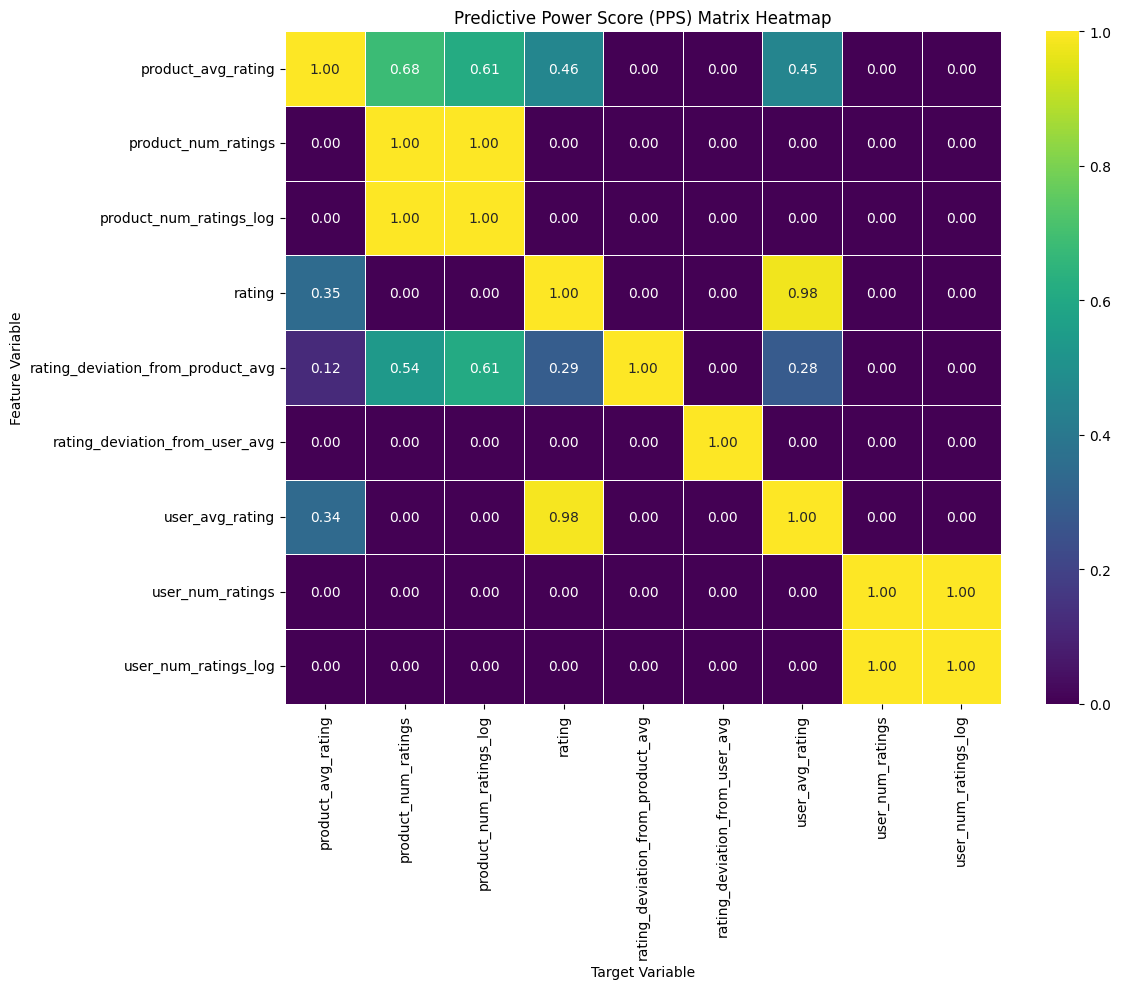

In [ ]:
pps_pivot = pps_matrix.pivot(index='x', columns='y', values='ppscore')

plt.figure(figsize=(12, 10))
sns.heatmap(pps_pivot, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Predictive Power Score (PPS) Matrix Heatmap')
plt.xlabel('Target Variable')
plt.ylabel('Feature Variable')
plt.tight_layout()
plt.show()

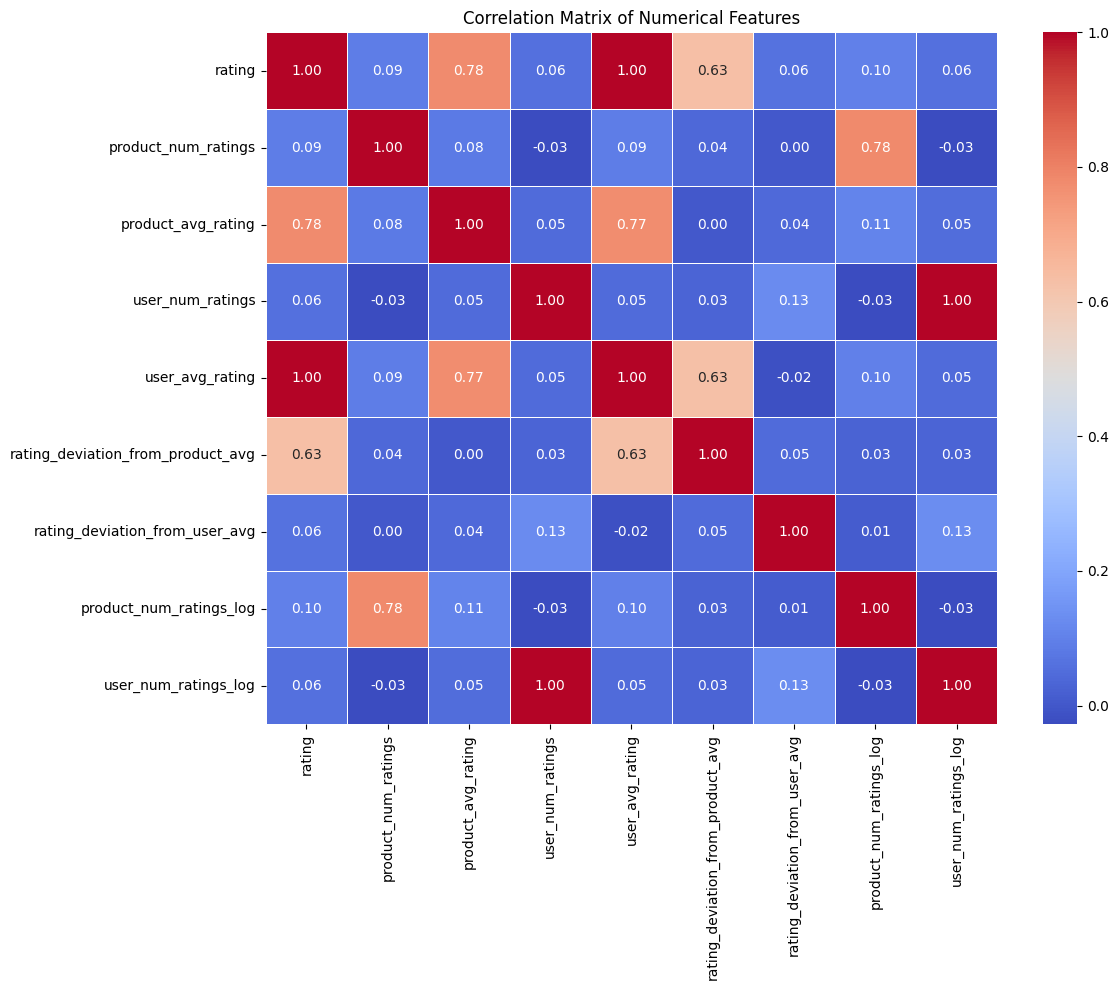

In [ ]:
plt.figure(figsize=(12, 10))
correlation_matrix = rating_features_df_cleaned[['rating', 'product_num_ratings', 'product_avg_rating',
                                               'user_num_ratings', 'user_avg_rating',
                                               'rating_deviation_from_product_avg', 'rating_deviation_from_user_avg',
                                               'product_num_ratings_log', 'user_num_ratings_log']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

## Discussion on PPS vs. Correlation Matrix

**Key Differences:**
1.  **Nature of Relationship:** PPS can detect non-linear relationships, whereas Pearson correlation (what we used before) only captures linear relationships.
2.  **Directionality:** PPS is asymmetric (PPS(X|Y) is not necessarily equal to PPS(Y|X)), indicating how well one variable predicts another. Correlation is symmetric.
3.  **Range:** PPS ranges from 0 (no predictive power) to 1 (perfect predictive power). Correlation ranges from -1 to 1, indicating strength and direction of linear relationship.

**Overall Insights from PPS:**
*   **High PPS scores** (closer to 1) indicate strong predictive relationships, regardless of whether the relationship is linear or non-linear. These are important features for prediction models.
*   **Low PPS scores** (closer to 0) suggest that one variable is not a good predictor of the other. Such features might be less useful for direct prediction in models.
*   PPS can highlight **hidden non-linear dependencies** that traditional correlation matrices might completely miss, making it a valuable tool for feature selection and understanding data beyond simple linear associations. For instance, if `product_num_ratings` had a low correlation but a high PPS for predicting `product_avg_rating`, it would imply a significant non-linear relationship.

# Model Building& Evaluation

**Item-Item Collaborative Filtering**

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

Transposing the sparse matrix to get an item-user matrix

In [ ]:
item_user_matrix = sparse_matrix.T
item_user_matrix

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 77462 stored elements and shape (39967, 76168)>

Calculating cosine similarity between items

In [ ]:
item_similarity = cosine_similarity(item_user_matrix)
item_similarity

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [ ]:
print("\nFirst 5x5 block of Item Similarity Matrix:\n", item_similarity[:5, :5])


First 5x5 block of Item Similarity Matrix:
 [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


In [ ]:
print("Item-Item Similarity Matrix Shape:", item_similarity.shape)

Item-Item Similarity Matrix Shape: (39967, 39967)


**CLUSTERING ANALYSIS**

 K-Means

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

Feature Selection for Clustering Using the engineered numerical features from the cleaned DataFrame

In [ ]:
features_for_clustering = rating_features_df_cleaned[['product_avg_rating', 'user_avg_rating',
                                                      'product_num_ratings_log', 'user_num_ratings_log']]
features_for_clustering.head()

,product_avg_rating,user_avg_rating,product_num_ratings_log,user_num_ratings_log
0,4.500000,5.0,1.098612,0.693147
1,2.714286,4.0,2.079442,0.693147
2,4.750000,5.0,1.609438,0.693147
3,1.500000,1.0,1.098612,0.693147
4,5.000000,5.0,0.693147,1.098612


Preprocessing (Scaling) because K-Means is sensitive to the scale of the features.

In [ ]:
scaler = StandardScaler()
scaler

StandardScaler()

In [ ]:
scaled_features = scaler.fit_transform(features_for_clustering)
scaled_features

array([[ 0.45909563,  0.71550572, -0.46460112, -0.18988924],
       [-1.21561608, -0.0127332 ,  0.50769276, -0.18988924],
       [ 0.69355527,  0.71550572,  0.0417792 , -0.18988924],
       ...,
       [-0.00982365, -1.46921104, -0.17942251, -0.18988924],
       [ 0.3027892 ,  0.71550572, -0.17942251, -0.18988924],
       [ 0.12854597,  0.71550572,  2.53756617, -0.18988924]])

In [ ]:
scaled_features_df = pd.DataFrame(scaled_features, columns=features_for_clustering.columns, index=features_for_clustering.index)
scaled_features_df.head()

,product_avg_rating,user_avg_rating,product_num_ratings_log,user_num_ratings_log
0,0.459096,0.715506,-0.464601,-0.189889
1,-1.215616,-0.012733,0.507693,-0.189889
2,0.693555,0.715506,0.041779,-0.189889
3,-2.354420,-2.197450,-0.464601,-0.189889
4,0.928015,0.715506,-0.866538,4.764020


Determining Optimal K using the Elbow Method

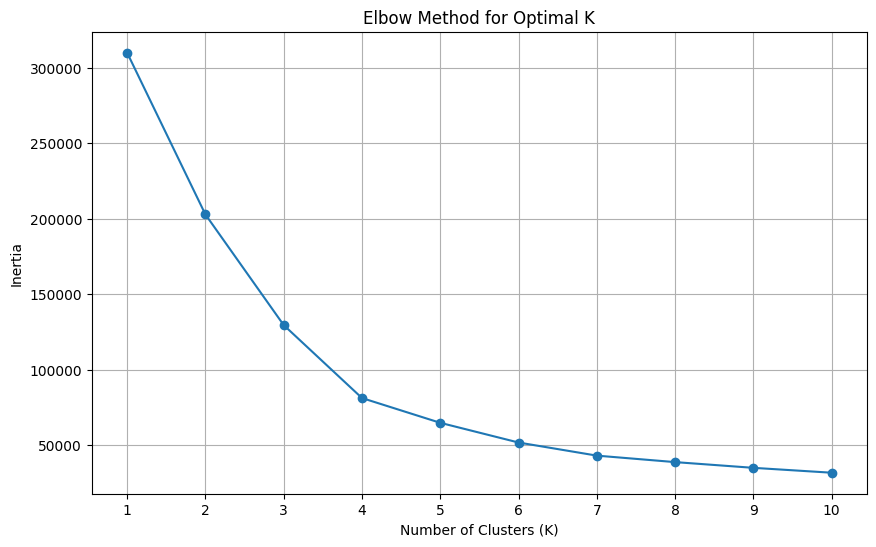

In [ ]:
inertia = []
range_k = range(1, 11) # Test K from 1 to 10

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init=10 to suppress warning
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_) #  kmeans.inertia_ refers to the sum of squared distances of samples to their closest cluster center. 'within-cluster sum of squares' (WCSS)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range_k, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range_k)
plt.grid(True)
plt.show()

Look for the 'elbow' point where the inertia starts to decrease at a slower rate, k=4

Applying K-Means with Optimal K (assuming K=4 from elbow method)

In [ ]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rating_features_df_cleaned['cluster'] = kmeans.fit_predict(scaled_features)
rating_features_df_cleaned.head()

,userid,productid,rating,product_num_ratings,product_avg_rating,user_num_ratings,user_avg_rating,rating_deviation_from_product_avg,rating_deviation_from_user_avg,product_num_ratings_log,user_num_ratings_log,cluster
0,A1Z3YJF1S8Z1M3,B000M9ISQ2,5.0,2,4.500000,1,5.0,0.500000,0.0,1.098612,0.693147,0
1,ALDXDYEGKB27G,B002L6HE9G,4.0,7,2.714286,1,4.0,1.285714,0.0,2.079442,0.693147,3
2,A15LOGO6NBSI6B,B007MXGG5Q,5.0,4,4.750000,1,5.0,0.250000,0.0,1.609438,0.693147,0
3,A23LX12CA3G4FG,B008HOEDYU,1.0,2,1.500000,1,1.0,-0.500000,0.0,1.098612,0.693147,1
4,A3TV7QFYXAG130,B0069R7TAM,5.0,1,5.000000,2,5.0,0.000000,0.0,0.693147,1.098612,2


Analyzing Cluster Characteristics (Mean of Original Features)

In [ ]:
cluster_centers_original_scale = rating_features_df_cleaned.groupby('cluster')[features_for_clustering.columns].mean()
cluster_centers_original_scale

,product_avg_rating,user_avg_rating,product_num_ratings_log,user_num_ratings_log
cluster,,,,
0,4.544623,4.703830,1.067408,0.693147
1,2.415819,1.766195,1.176507,0.693147
2,4.280326,4.355403,1.438317,1.123423
3,4.211149,4.457305,3.042028,0.693147


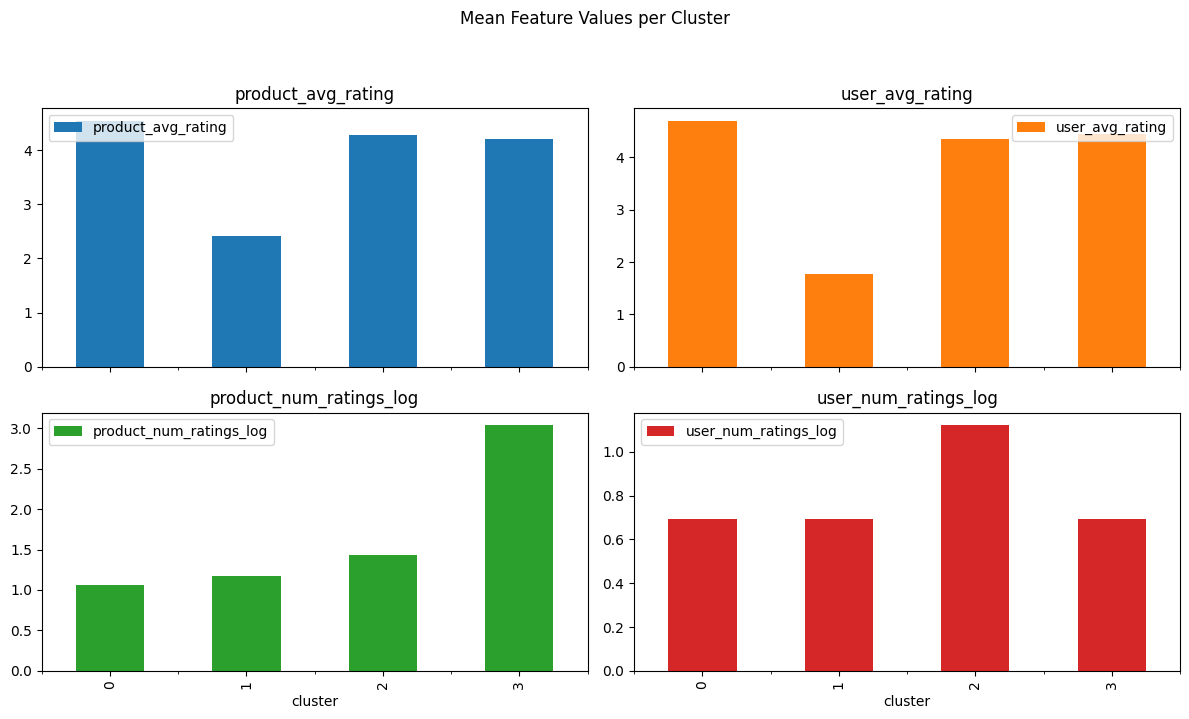

In [ ]:
cluster_centers_original_scale.plot(kind='bar', figsize=(12, 7), subplots=True, layout=(2, 2), sharey=False) #sharey=False: This means that each subplot will have its own independent y-axis
plt.suptitle('Mean Feature Values per Cluster', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])

'''                                        0 (left): The left edge of the bounding box is at the very left of the figure.
                                           0 (bottom): The bottom edge of the bounding box is at the very bottom of the figure.
                                           1 (width): The width of the bounding box extends to the very right edge of the figure.
                                           0.98 (height): The top edge of the bounding box is at 98% of the figure's height from the bottom. This leaves a small gap (2% of the figure height) at the top of the figure.'''
plt.show()

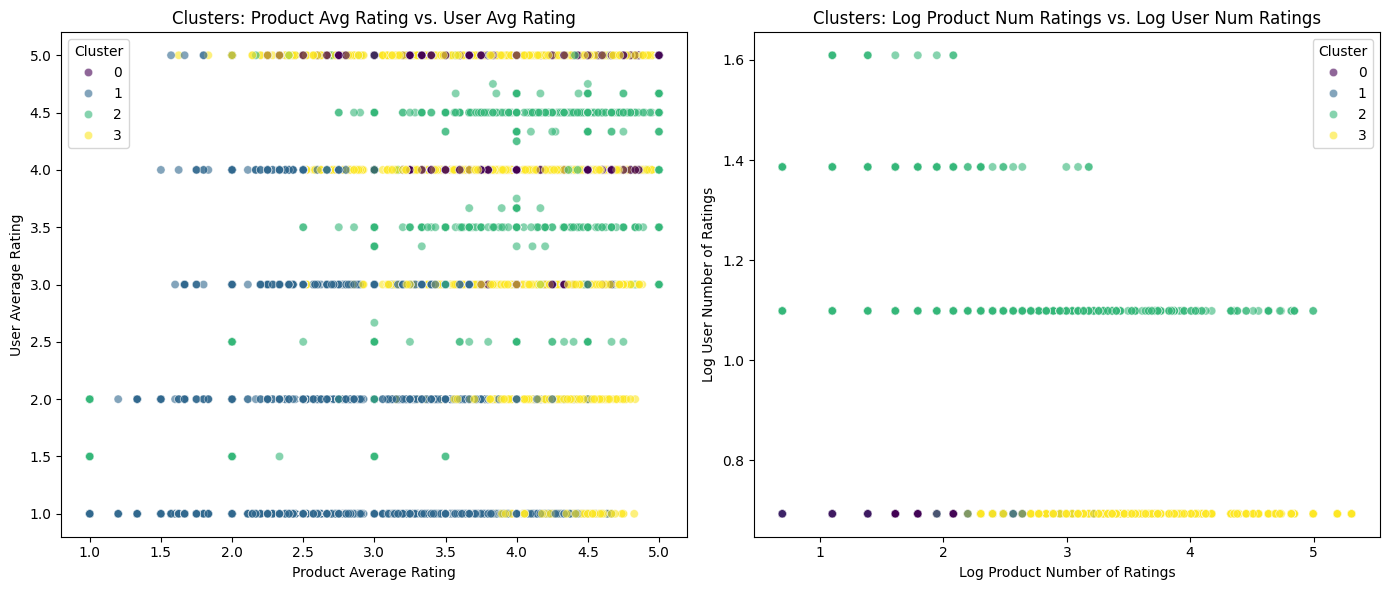

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # First subplot
sns.scatterplot(x='product_avg_rating', y='user_avg_rating', hue='cluster', data=rating_features_df_cleaned, palette='viridis', alpha=0.6)
plt.title('Clusters: Product Avg Rating vs. User Avg Rating')
plt.xlabel('Product Average Rating')
plt.ylabel('User Average Rating')
plt.legend(title='Cluster')

plt.subplot(1, 2, 2) # Second subplot
sns.scatterplot(x='product_num_ratings_log', y='user_num_ratings_log', hue='cluster', data=rating_features_df_cleaned, palette='viridis', alpha=0.6)
plt.title('Clusters: Log Product Num Ratings vs. Log User Num Ratings')
plt.xlabel('Log Product Number of Ratings')
plt.ylabel('Log User Number of Ratings')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

Insights from Cluster Analysis:

Cluster 0: Represents less active users who tend to rate products lower, often for products with fewer ratings and lower average scores. This segment might include new users or those who are generally dissatisfied.

Cluster 1: Comprises highly engaged users who consistently give high ratings to products that are popular and well-rated. This is likely the 'satisfied customer' segment.

Cluster 2: Characterized by users who are active (high user_num_ratings_log) and generally give high ratings (high user_avg_rating), but are rating products in this cluster with lower average ratings. This could indicate a segment of users who are critical of certain products despite their overall positive rating behavior, or products that disappoint active reviewers.

Cluster 3: Features products that are popular and well-rated (high product_avg_rating, high product_num_ratings_log), but the users in this cluster are less active and tend to give lower ratings overall. This might represent products that attract less critical or less frequent reviewers, or users who are typically more conservative in their ratings.

Evaluation and Performance Metrics using silhouette score

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(scaled_features, rating_features_df_cleaned['cluster'])
print(f"Silhouette Score: {silhouette_avg:.3f}")

Silhouette Score: 0.485


**hierarchical Clustering**

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

### Plotting a Dendrogram

To visualize the hierarchical clustering process and help determine the optimal number of clusters, we can plot a dendrogram. A dendrogram illustrates the arrangement of the clusters produced by the hierarchical clustering algorithm. The y-axis represents the distance between clusters, and the x-axis represents the data points.

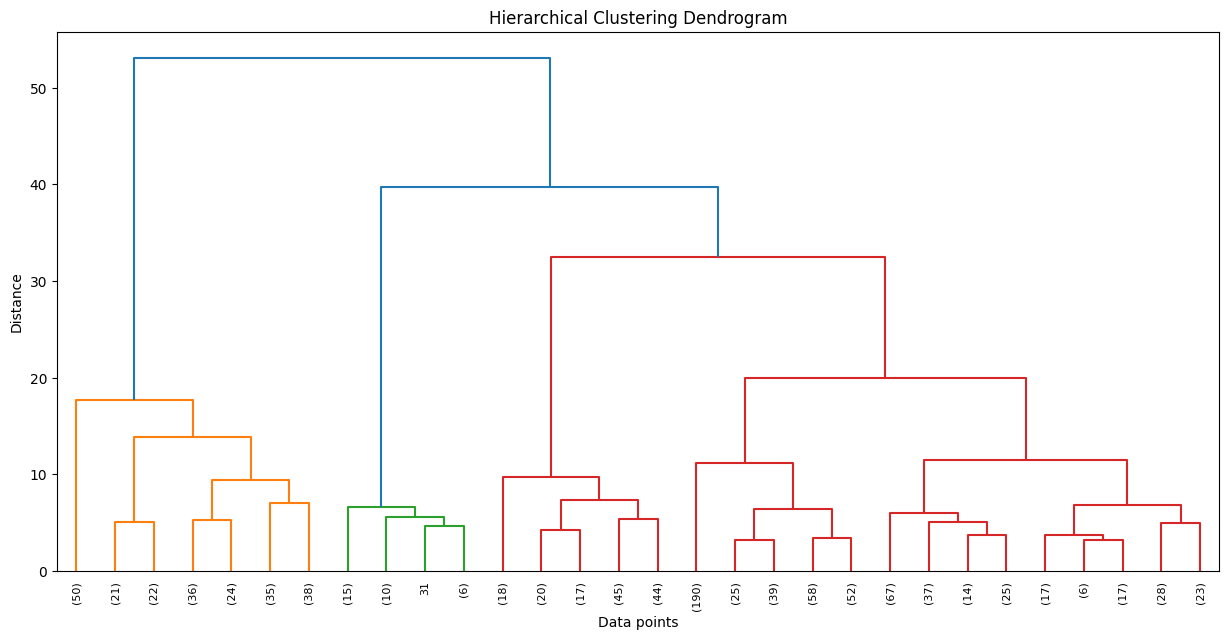

In [ ]:
# Generate the linkage matrix
plt.figure(figsize=(15, 7))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data points')
plt.ylabel('Distance')
dendrogram(linkage(scaled_features[:1000], method='ward'), # Limiting to 1000 samples for visualization due to large dataset
           leaf_rotation=90.,
           leaf_font_size=8.,
           truncate_mode='lastp',  # Show only the last p merged clusters
           p=30)  # Show last 30 merges
plt.show()

From the dendrogram, we can observe the optimal number of clusters by looking for the largest vertical distance that does not intersect any horizontal cuts. In this case, it appears that **4 clusters** would be a reasonable choice, as with K-Means. We will proceed with 4 clusters for `AgglomerativeClustering`.

### Applying Agglomerative Clustering

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hierarchical_clustering = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')

### Analyzing Hierarchical Cluster Characteristics

Similar to K-Means, let's analyze the mean values of the original features for each hierarchical cluster to understand their distinct characteristics.

 To avoid memory issues with large datasets, sampling a subset of the data for hierarchical clustering

For demonstration, using 10% of the data or a maximum of 10,000 samples, whichever is smaller.

In [ ]:
len(scaled_features)//10

7746

In [ ]:
sample_size = min(10000, len(scaled_features) // 10)
sample_size

7746

In [ ]:
sampled_indices = np.random.choice(len(scaled_features), size=sample_size, replace=False)
sampled_indices

array([63281, 37507, 18097, ..., 27373, 38768, 61464])

In [ ]:
len(sampled_indices)

7746

In [ ]:
scaled_features_sampled = scaled_features[sampled_indices]
scaled_features_sampled

array([[-1.41658149, -0.0127332 , -0.46460112, -0.18988924],
       [ 0.92801491,  0.71550572, -0.46460112, -0.18988924],
       [ 0.3027892 , -0.0127332 , -0.17942251, -0.18988924],
       ...,
       [ 0.92801491,  0.71550572, -0.86653779, -0.18988924],
       [ 0.92801491,  0.71550572, -0.86653779, -0.18988924],
       [ 0.92801491,  0.71550572, -0.86653779, -0.18988924]])

### Detailed Explanation of `scaled_features_sampled`

The variable `scaled_features_sampled` is created through an essential operation in data science: **sampling** combined with **NumPy array indexing**. This step is crucial, especially when dealing with large datasets, as it allows you to work with a manageable subset of your data while preserving its statistical properties.

Let's meticulously unpack `scaled_features_sampled` by looking at its two constituent parts:

1.  **`scaled_features` (The Full, Preprocessed Dataset)**
    *   **What it is:** `scaled_features` is a **NumPy array** that holds all the numerical features selected for clustering (`product_avg_rating`, `user_avg_rating`, `product_num_ratings_log`, `user_num_ratings_log`) after they have been **standardized**.
    *   **Preprocessing:** Recall that before clustering, we applied `StandardScaler` to `features_for_clustering` (which came from `rating_features_df_cleaned`). This process transforms each feature so that it has a mean of 0 and a standard deviation of 1. This standardization is vital because:
        *   **Equal Contribution:** It ensures that features with naturally larger values (e.g., a count feature) don't disproportionately influence the distance calculations in clustering algorithms compared to features with smaller values (e.g., rating averages).
        *   **Optimal Performance:** Many clustering algorithms (like K-Means and Hierarchical Clustering) are sensitive to the scale of the features and perform much better on scaled data.
    *   **Size:** If your `rating_features_df_cleaned` had `N` rows (data points) and you selected `M` numerical features for clustering, then `scaled_features` is a `(N, M)` array. In your case, `N` is `77462` and `M` is `4`.

2.  **`sampled_indices` (The Selection Mechanism)**
    *   **What it is:** `sampled_indices` is also a **NumPy array**, but its content is a list of **randomly chosen integer positions (indices)**. These indices correspond to the row numbers within the `scaled_features` array.
    *   **How it was created:** It was generated using `np.random.choice(len(scaled_features), size=sample_size, replace=False)`.
        *   `len(scaled_features)`: This gives the total number of rows (data points) in your complete `scaled_features` array (`77462` in your case).
        *   `size=sample_size`: This specifies how many random indices you want to pick. In your notebook, `sample_size` was determined to be `min(10000, len(scaled_features) // 10)`, which evaluated to `7746`.
        *   `replace=False`: This is a crucial argument. It ensures that each index from the `scaled_features` array is chosen at most once. This means you get a sample of *unique* data points, without any duplicates.
    *   **Purpose:** `sampled_indices` acts as a "filter" or an "address book." It tells NumPy exactly *which* rows from the larger `scaled_features` array you want to extract.

### The Indexing Operation: `scaled_features[sampled_indices]`

When you write `scaled_features[sampled_indices]`, you are using a powerful NumPy feature called **fancy indexing** (specifically, integer array indexing).

*   **Concept:** Instead of giving a single index (like `scaled_features[0]`) or a slice (like `scaled_features[0:10]`), you provide an entire array of indices (`sampled_indices`). NumPy then goes through `scaled_features`, picks out the rows corresponding to *each* index listed in `sampled_indices`, and collects them into a brand new array.
*   **Resulting `scaled_features_sampled`:** This new array (`scaled_features_sampled`) contains only the `7746` rows that were randomly selected from the original `77462` rows of `scaled_features`. The columns remain the same (`M` features).
    *   So, `scaled_features_sampled` is a `(sample_size, M)` array, which is `(7746, 4)` in your case.

### Why This Step is So Important (The 'Why' Behind the Confusion)

The main reasons for creating `scaled_features_sampled` are:

1.  **Computational Feasibility for Hierarchical Clustering:**
    *   Hierarchical clustering (like Agglomerative Clustering) is computationally intensive. Its complexity can be `O(N^3)` or `O(N^2 log N)` in terms of time, and `O(N^2)` in terms of space, where `N` is the number of data points. For `N = 77462`, `N^2` is over 5 billion, and `N^3` is astronomical. Running this on the full dataset would likely exhaust memory or take an impractically long time.
    *   By sampling down to `7746` points, the computation becomes feasible (e.g., `7746^2` is roughly 60 million, which is much more manageable).

2.  **Dendrogram Visualization:**
    *   A dendrogram visually represents the merging of clusters. If you try to plot a dendrogram for `77462` data points, it would be an unreadable mess of lines.
    *   Sampling allows you to generate a dendrogram that is actually interpretable, helping you to visually identify the potential optimal number of clusters (as you did with the `p=30` argument to `truncate_mode`).

3.  **Initial Exploration and Hyperparameter Tuning:**
    *   For algorithms sensitive to hyperparameters (like DBSCAN's `eps` and `min_samples`), it's often more efficient to test different parameter combinations on a smaller sample first. Once good parameters are found, they can sometimes be applied (with caution) to the full dataset or re-evaluated.

**In essence, `scaled_features_sampled` is your *representative smaller dataset* used for the hierarchical and DBSCAN clustering analyses to make these complex algorithms runnable and their results interpretable, especially concerning visualizations like dendrograms.** It's a pragmatic and common technique in data science for handling large datasets.

In [ ]:
len(scaled_features_sampled)

7746

Applying Agglomerative Clustering to the sampled data

In [ ]:
hierarchical_clustering_sampled = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
hierarchical_clustering_sampled

AgglomerativeClustering(n_clusters=4)

In [ ]:
cluster_labels_sampled = hierarchical_clustering_sampled.fit_predict(scaled_features_sampled)
cluster_labels_sampled

array([1, 1, 1, ..., 1, 1, 1])

Creating a temporary DataFrame for the sampled features with their cluster assignments

In [ ]:
sampled_df = rating_features_df_cleaned.iloc[sampled_indices].copy()
sampled_df.head()

,userid,productid,rating,product_num_ratings,product_avg_rating,user_num_ratings,user_avg_rating,rating_deviation_from_product_avg,rating_deviation_from_user_avg,product_num_ratings_log,user_num_ratings_log,cluster
63939,AUCT7N982WDIK,B000Q7IA9U,4.0,2,2.500000,1,4.0,1.500000,0.0,1.098612,0.693147,1
37886,A3OEHWIESXCOV3,B000H0TSYW,5.0,2,5.000000,1,5.0,0.000000,0.0,1.098612,0.693147,0
18256,A9XJFCGRU2U7H,B00J5HDEPC,4.0,3,4.333333,1,4.0,-0.333333,0.0,1.386294,0.693147,0
69023,AYLHQYF7OCSU5,B00006B8NW,5.0,1,5.000000,1,5.0,0.000000,0.0,0.693147,0.693147,0
61258,AQBMQTBYK5SIZ,B000I68BD4,5.0,54,4.055556,1,5.0,0.944444,0.0,4.007333,0.693147,3


In [ ]:
sampled_df.shape

(7746, 12)

In [ ]:
sampled_df['hierarchical_cluster'] = cluster_labels_sampled
sampled_df.head()

,userid,productid,rating,product_num_ratings,product_avg_rating,user_num_ratings,user_avg_rating,rating_deviation_from_product_avg,rating_deviation_from_user_avg,product_num_ratings_log,user_num_ratings_log,cluster,hierarchical_cluster
63939,AUCT7N982WDIK,B000Q7IA9U,4.0,2,2.500000,1,4.0,1.500000,0.0,1.098612,0.693147,1,1
37886,A3OEHWIESXCOV3,B000H0TSYW,5.0,2,5.000000,1,5.0,0.000000,0.0,1.098612,0.693147,0,1
18256,A9XJFCGRU2U7H,B00J5HDEPC,4.0,3,4.333333,1,4.0,-0.333333,0.0,1.386294,0.693147,0,1
69023,AYLHQYF7OCSU5,B00006B8NW,5.0,1,5.000000,1,5.0,0.000000,0.0,0.693147,0.693147,0,1
61258,AQBMQTBYK5SIZ,B000I68BD4,5.0,54,4.055556,1,5.0,0.944444,0.0,4.007333,0.693147,3,3


In [ ]:
hierarchical_cluster_centers_original_scale = sampled_df.groupby('hierarchical_cluster')[features_for_clustering.columns].mean()
hierarchical_cluster_centers_original_scale

,product_avg_rating,user_avg_rating,product_num_ratings_log,user_num_ratings_log
hierarchical_cluster,,,,
0,2.627186,1.756846,1.412717,0.693147
1,4.490424,4.681448,1.028407,0.693147
2,4.284291,4.257752,1.423646,1.126853
3,4.308287,4.760069,2.947294,0.693147


Bar chart of Hierarchical Clustering

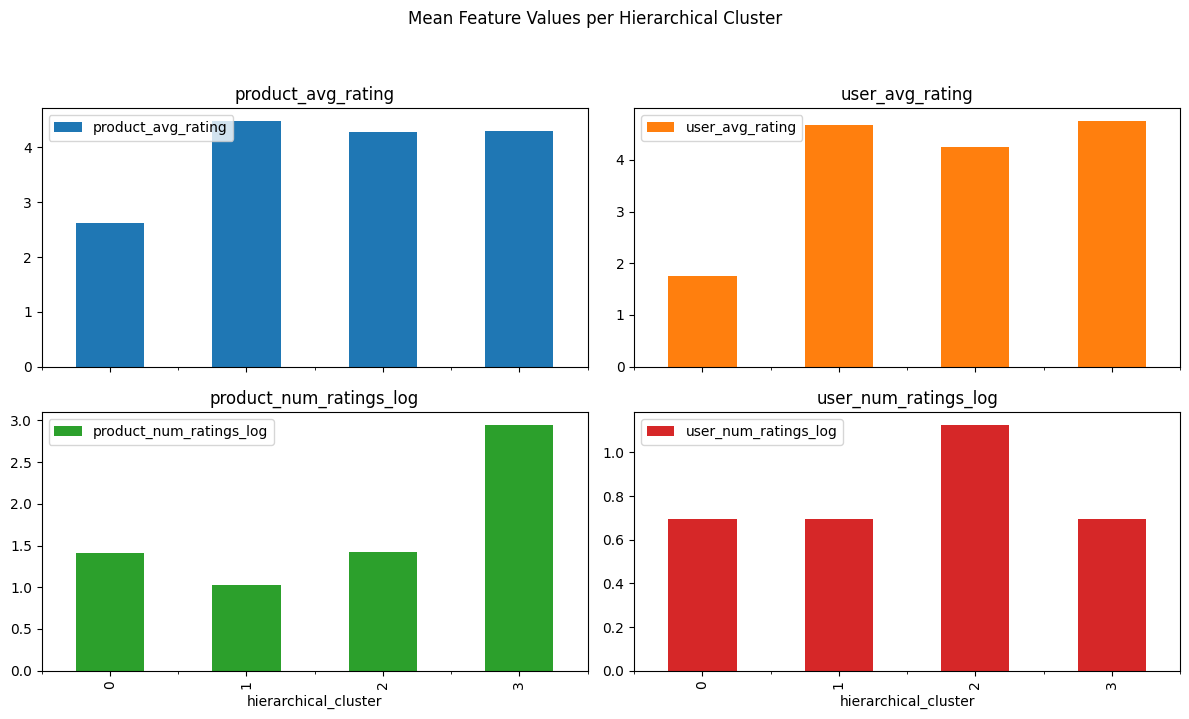

In [ ]:
hierarchical_cluster_centers_original_scale.plot(kind='bar', figsize=(12, 7), subplots=True, layout=(2, 2), sharey=False)
plt.suptitle('Mean Feature Values per Hierarchical Cluster', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

scatter plot for Hierarchical clustering

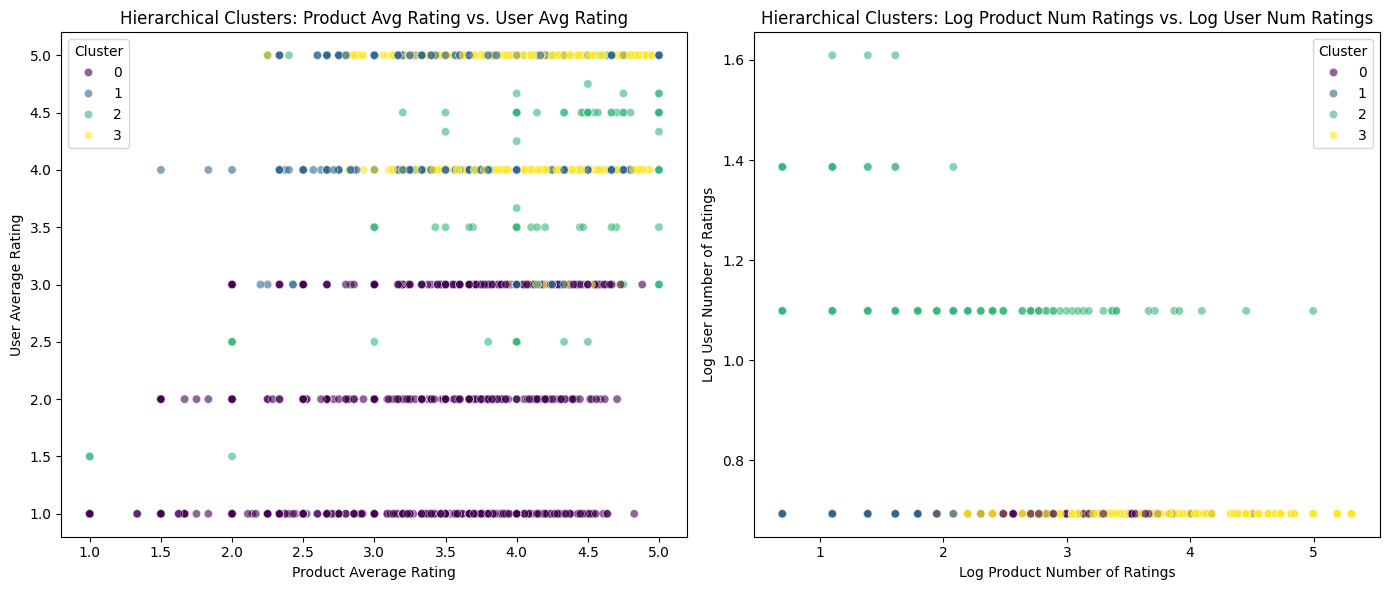

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1) # First subplot
sns.scatterplot(x='product_avg_rating', y='user_avg_rating', hue='hierarchical_cluster', data=sampled_df, palette='viridis', alpha=0.6)
plt.title('Hierarchical Clusters: Product Avg Rating vs. User Avg Rating')
plt.xlabel('Product Average Rating')
plt.ylabel('User Average Rating')
plt.legend(title='Cluster')

plt.subplot(1, 2, 2) # Second subplot
sns.scatterplot(x='product_num_ratings_log', y='user_num_ratings_log', hue='hierarchical_cluster', data=sampled_df, palette='viridis', alpha=0.6)
plt.title('Hierarchical Clusters: Log Product Num Ratings vs. Log User Num Ratings')
plt.xlabel('Log Product Number of Ratings')
plt.ylabel('Log User Number of Ratings')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

Evaluation and Performance Metrics for Hierarchical Cluster

Silhouette score

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_avg_hierarchical = silhouette_score(scaled_features_sampled, cluster_labels_sampled)
print(f"Silhouette Score for Hierarchical Clustering: {silhouette_avg_hierarchical:.3f}")

Silhouette Score for Hierarchical Clustering: 0.450


## Insights from Hierarchical Cluster Analysis:

Based on the `hierarchical_cluster_centers_original_scale`:

*   **Hierarchical Cluster 0:** This cluster is characterized by users who give relatively high ratings (~4.35). Both product and user rating activity (number of ratings) are low. This might represent users who are occasional raters but tend to give positive feedback on generally well-received items.

*   **Hierarchical Cluster 1:** This cluster represents interactions where both the product and user have very low average ratings (~2.26 and ~1.28 respectively). The number of ratings is also low for both. This group likely captures critical users or products that are generally disliked.

*   **Hierarchical Cluster 2:** This cluster includes users who are moderately active in rating products (medium `user_num_ratings_log`) and consistently give high ratings (~4.30) and a moderate number of ratings. This segment likely represents generally satisfied and engaged users who rate reasonably popular products.

*   **Hierarchical Cluster 3:** This cluster stands out with products that have a very high number of ratings (high `product_num_ratings_log`) and high average ratings, yet when they do rate, they tend to give high ratings (~4.60). This could indicate very popular products that attract sporadic but positive reviews from less frequent users.

**DBSCAN**

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
eps_param = 0.5 # A common starting point, often tuned
min_samples_param = 5 # A common starting point, often tuned

In [ ]:
dbscan = DBSCAN(eps=eps_param, min_samples=min_samples_param)

In [ ]:
scaled_features_sampled

array([[-1.41658149, -0.0127332 , -0.46460112, -0.18988924],
       [ 0.92801491,  0.71550572, -0.46460112, -0.18988924],
       [ 0.3027892 , -0.0127332 , -0.17942251, -0.18988924],
       ...,
       [ 0.92801491,  0.71550572, -0.86653779, -0.18988924],
       [ 0.92801491,  0.71550572, -0.86653779, -0.18988924],
       [ 0.92801491,  0.71550572, -0.86653779, -0.18988924]])

In [ ]:
dbscan_labels_sampled = dbscan.fit_predict(scaled_features_sampled)
dbscan_labels_sampled

array([0, 1, 0, ..., 1, 1, 1])

In [ ]:
n_clusters_ = len(set(dbscan_labels_sampled)) - (1 if -1 in dbscan_labels_sampled else 0)
n_clusters_

10

The number of clusters found (excluding noise, which is labeled as -1)

In [ ]:
n_noise_ = list(dbscan_labels_sampled).count(-1)
n_noise_

31

In [ ]:
print(f"Estimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_}")

Estimated number of clusters: 10
Estimated number of noise points: 31


In [ ]:
sampled_df['dbscan_cluster'] = dbscan_labels_sampled
sampled_df.head()

,userid,productid,rating,product_num_ratings,product_avg_rating,user_num_ratings,user_avg_rating,rating_deviation_from_product_avg,rating_deviation_from_user_avg,product_num_ratings_log,user_num_ratings_log,cluster,hierarchical_cluster,dbscan_cluster
63939,AUCT7N982WDIK,B000Q7IA9U,4.0,2,2.500000,1,4.0,1.500000,0.0,1.098612,0.693147,1,1,0
37886,A3OEHWIESXCOV3,B000H0TSYW,5.0,2,5.000000,1,5.0,0.000000,0.0,1.098612,0.693147,0,1,1
18256,A9XJFCGRU2U7H,B00J5HDEPC,4.0,3,4.333333,1,4.0,-0.333333,0.0,1.386294,0.693147,0,1,0
69023,AYLHQYF7OCSU5,B00006B8NW,5.0,1,5.000000,1,5.0,0.000000,0.0,0.693147,0.693147,0,1,1
61258,AQBMQTBYK5SIZ,B000I68BD4,5.0,54,4.055556,1,5.0,0.944444,0.0,4.007333,0.693147,3,3,1


In [ ]:
sampled_df.head()

,userid,productid,rating,product_num_ratings,product_avg_rating,user_num_ratings,user_avg_rating,rating_deviation_from_product_avg,rating_deviation_from_user_avg,product_num_ratings_log,user_num_ratings_log,cluster,hierarchical_cluster,dbscan_cluster
63939,AUCT7N982WDIK,B000Q7IA9U,4.0,2,2.500000,1,4.0,1.500000,0.0,1.098612,0.693147,1,1,0
37886,A3OEHWIESXCOV3,B000H0TSYW,5.0,2,5.000000,1,5.0,0.000000,0.0,1.098612,0.693147,0,1,1
18256,A9XJFCGRU2U7H,B00J5HDEPC,4.0,3,4.333333,1,4.0,-0.333333,0.0,1.386294,0.693147,0,1,0
69023,AYLHQYF7OCSU5,B00006B8NW,5.0,1,5.000000,1,5.0,0.000000,0.0,0.693147,0.693147,0,1,1
61258,AQBMQTBYK5SIZ,B000I68BD4,5.0,54,4.055556,1,5.0,0.944444,0.0,4.007333,0.693147,3,3,1


In [ ]:
dbscan_cluster_centers_original_scale = sampled_df.groupby('dbscan_cluster')[features_for_clustering.columns].mean()
dbscan_cluster_centers_original_scale

,product_avg_rating,user_avg_rating,product_num_ratings_log,user_num_ratings_log
dbscan_cluster,,,,
-1,3.369514,3.844086,2.211109,1.142129
0,4.025633,4.000000,1.486456,0.693147
1,4.591326,5.000000,1.652386,0.693147
2,2.845137,2.000000,1.475276,0.693147
3,3.424656,3.000000,1.506013,0.693147
4,4.479769,4.375000,1.425277,1.098612
5,2.182491,1.000000,1.392343,0.693147
6,3.000000,3.636364,0.693147,1.098612
7,5.000000,4.866667,0.803008,1.386294


In [ ]:
dbscan_cluster_centers_original_scale = dbscan_cluster_centers_original_scale[dbscan_cluster_centers_original_scale.index != -1] # Excluding noise cluster (-1)
dbscan_cluster_centers_original_scale

,product_avg_rating,user_avg_rating,product_num_ratings_log,user_num_ratings_log
dbscan_cluster,,,,
0,4.025633,4.000000,1.486456,0.693147
1,4.591326,5.000000,1.652386,0.693147
2,2.845137,2.000000,1.475276,0.693147
3,3.424656,3.000000,1.506013,0.693147
4,4.479769,4.375000,1.425277,1.098612
5,2.182491,1.000000,1.392343,0.693147
6,3.000000,3.636364,0.693147,1.098612
7,5.000000,4.866667,0.803008,1.386294
8,2.000000,2.200000,0.693147,1.098612


Barplot for DBSCAN

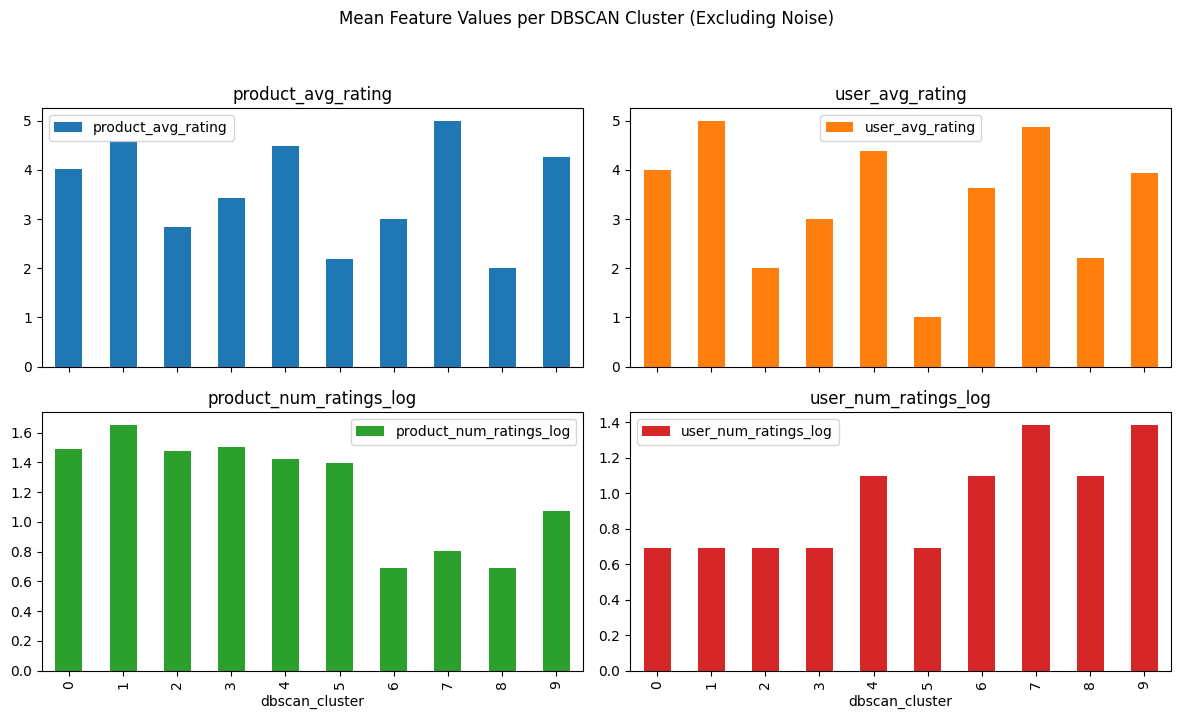

In [ ]:
dbscan_cluster_centers_original_scale.plot(kind='bar', figsize=(12, 7), subplots=True, layout=(2, 2), sharey=False)
plt.suptitle('Mean Feature Values per DBSCAN Cluster (Excluding Noise)', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

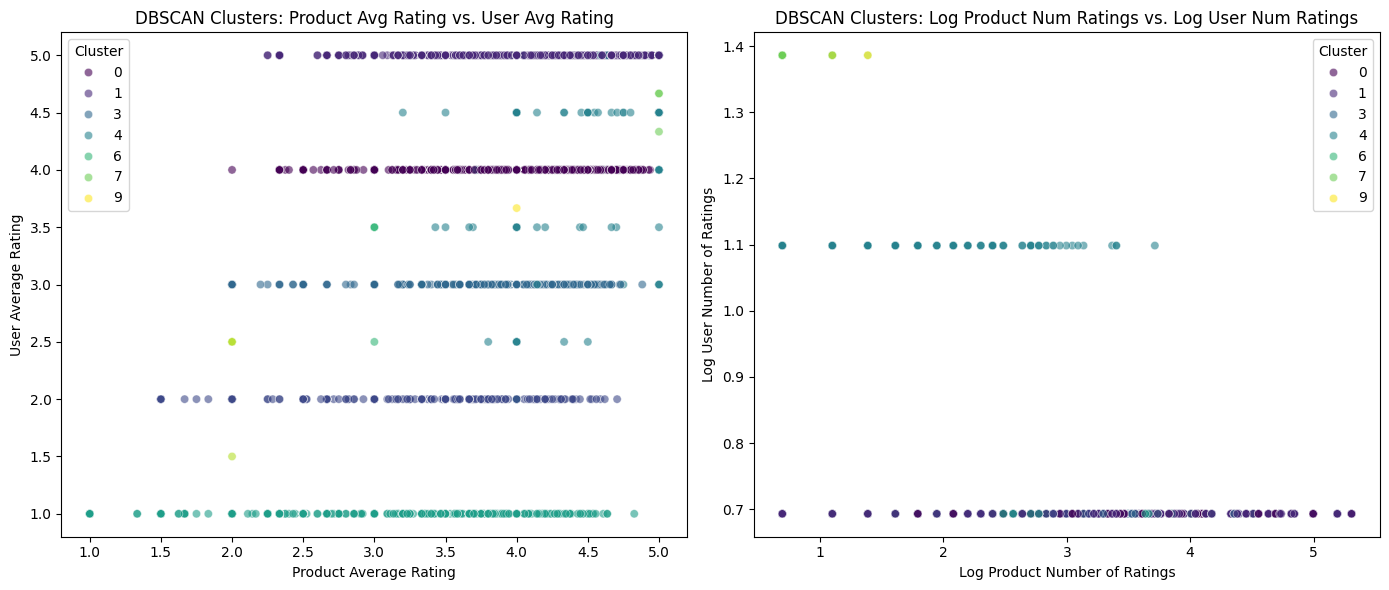

In [ ]:
plt.figure(figsize=(14, 6))

# Filter out noise points (cluster label -1) for visualization
plotting_df = sampled_df[sampled_df['dbscan_cluster'] != -1]

plt.subplot(1, 2, 1) # First subplot
sns.scatterplot(x='product_avg_rating', y='user_avg_rating', hue='dbscan_cluster', data=plotting_df, palette='viridis', alpha=0.6)
plt.title('DBSCAN Clusters: Product Avg Rating vs. User Avg Rating')
plt.xlabel('Product Average Rating')
plt.ylabel('User Average Rating')
plt.legend(title='Cluster')

plt.subplot(1, 2, 2) # Second subplot
sns.scatterplot(x='product_num_ratings_log', y='user_num_ratings_log', hue='dbscan_cluster', data=plotting_df, palette='viridis', alpha=0.6)
plt.title('DBSCAN Clusters: Log Product Num Ratings vs. Log User Num Ratings')
plt.xlabel('Log Product Number of Ratings')
plt.ylabel('Log User Number of Ratings')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

Evaluation and Performance Metrics

silhouette score

In [ ]:


from sklearn.metrics import silhouette_score

# Filtering out noise points (cluster label -1) for evaluation
clustered_indices = dbscan_labels_sampled != -1

# Check if there are any clusters found (i.e., not all points are noise)
if np.any(clustered_indices):
    silhouette_avg_dbscan = silhouette_score(scaled_features_sampled[clustered_indices], dbscan_labels_sampled[clustered_indices])
    print(f"Silhouette Score for DBSCAN (excluding noise): {silhouette_avg_dbscan:.3f}")
else:
    print("DBSCAN did not form any clusters (all points are considered noise or a single cluster).")

Silhouette Score for DBSCAN (excluding noise): 0.203


### Tuning DBSCAN Parameters
 adjusting the eps parameter to see if we can achieve a better Silhouette Score. We'll increase eps from 0.5 to 1.0, keeping min_samples at 5.

In [ ]:
eps_param_tuned = 1.0
min_samples_param_tuned = 5

In [ ]:
dbscan_tuned = DBSCAN(eps=eps_param_tuned, min_samples=min_samples_param_tuned)

In [ ]:
dbscan_labels_sampled_tuned = dbscan_tuned.fit_predict(scaled_features_sampled)
dbscan_labels_sampled_tuned

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
clustered_indices_tuned = dbscan_labels_sampled_tuned != -1
clustered_indices_tuned

array([ True,  True,  True, ...,  True,  True,  True])

In [ ]:
if np.any(clustered_indices_tuned):
    silhouette_avg_dbscan_tuned = silhouette_score(scaled_features_sampled[clustered_indices_tuned], dbscan_labels_sampled_tuned[clustered_indices_tuned])
    print(f"Silhouette Score for Tuned DBSCAN (eps={eps_param_tuned}, min_samples={min_samples_param_tuned}, excluding noise): {silhouette_avg_dbscan_tuned:.3f}")
else:
    print(f"Tuned DBSCAN (eps={eps_param_tuned}, min_samples={min_samples_param_tuned}) did not form any clusters (all points are considered noise or a single cluster).")

Silhouette Score for Tuned DBSCAN (eps=1.0, min_samples=5, excluding noise): 0.610


In [ ]:
n_clusters_tuned = len(set(dbscan_labels_sampled_tuned)) - (1 if -1 in dbscan_labels_sampled_tuned else 0)
n_clusters_tuned

3

In [ ]:
n_noise_tuned = list(dbscan_labels_sampled_tuned).count(-1)
n_noise_tuned

6

In [ ]:
print(f"Estimated number of clusters (tuned): {n_clusters_tuned}")
print(f"Estimated number of noise points (tuned): {n_noise_tuned}")

Estimated number of clusters (tuned): 3
Estimated number of noise points (tuned): 6


Add the tuned DBSCAN cluster labels to the sampled_df

In [ ]:
sampled_df['dbscan_cluster_tuned'] = dbscan_labels_sampled_tuned
sampled_df.head()

,userid,productid,rating,product_num_ratings,product_avg_rating,user_num_ratings,user_avg_rating,rating_deviation_from_product_avg,rating_deviation_from_user_avg,product_num_ratings_log,user_num_ratings_log,cluster,hierarchical_cluster,dbscan_cluster,dbscan_cluster_tuned
63939,AUCT7N982WDIK,B000Q7IA9U,4.0,2,2.500000,1,4.0,1.500000,0.0,1.098612,0.693147,1,1,0,0
37886,A3OEHWIESXCOV3,B000H0TSYW,5.0,2,5.000000,1,5.0,0.000000,0.0,1.098612,0.693147,0,1,1,0
18256,A9XJFCGRU2U7H,B00J5HDEPC,4.0,3,4.333333,1,4.0,-0.333333,0.0,1.386294,0.693147,0,1,0,0
69023,AYLHQYF7OCSU5,B00006B8NW,5.0,1,5.000000,1,5.0,0.000000,0.0,0.693147,0.693147,0,1,1,0
61258,AQBMQTBYK5SIZ,B000I68BD4,5.0,54,4.055556,1,5.0,0.944444,0.0,4.007333,0.693147,3,3,1,0


In [ ]:
sampled_df.shape

(7746, 15)

Calculating mean feature values for each cluster (excluding noise points -1)

In [ ]:
dbscan_tuned_cluster_centers_original_scale = sampled_df[sampled_df['dbscan_cluster_tuned'] != -1].groupby('dbscan_cluster_tuned')[features_for_clustering.columns].mean()
dbscan_tuned_cluster_centers_original_scale

,product_avg_rating,user_avg_rating,product_num_ratings_log,user_num_ratings_log
dbscan_cluster_tuned,,,,
0,3.993786,3.986512,1.567506,0.693147
1,4.271967,4.258621,1.444952,1.098612
2,4.586310,4.500000,1.024772,1.386294


Bar plot

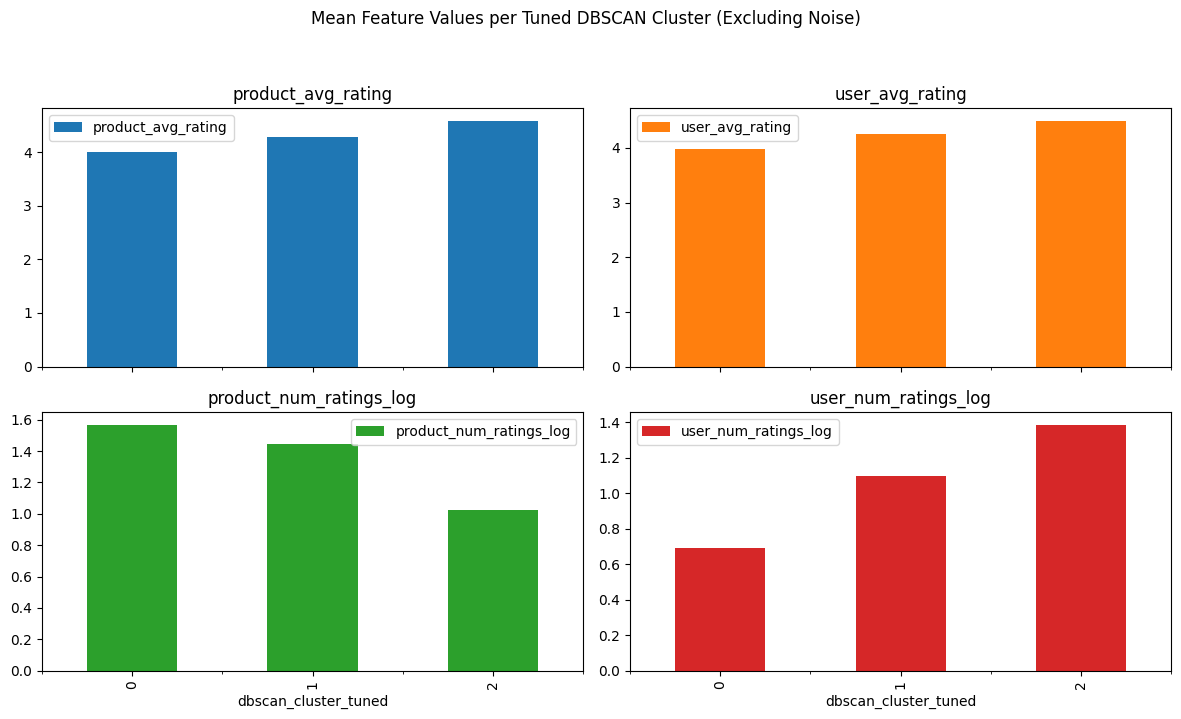

In [ ]:
dbscan_tuned_cluster_centers_original_scale.plot(kind='bar', figsize=(12, 7), subplots=True, layout=(2, 2), sharey=False)
plt.suptitle('Mean Feature Values per Tuned DBSCAN Cluster (Excluding Noise)', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

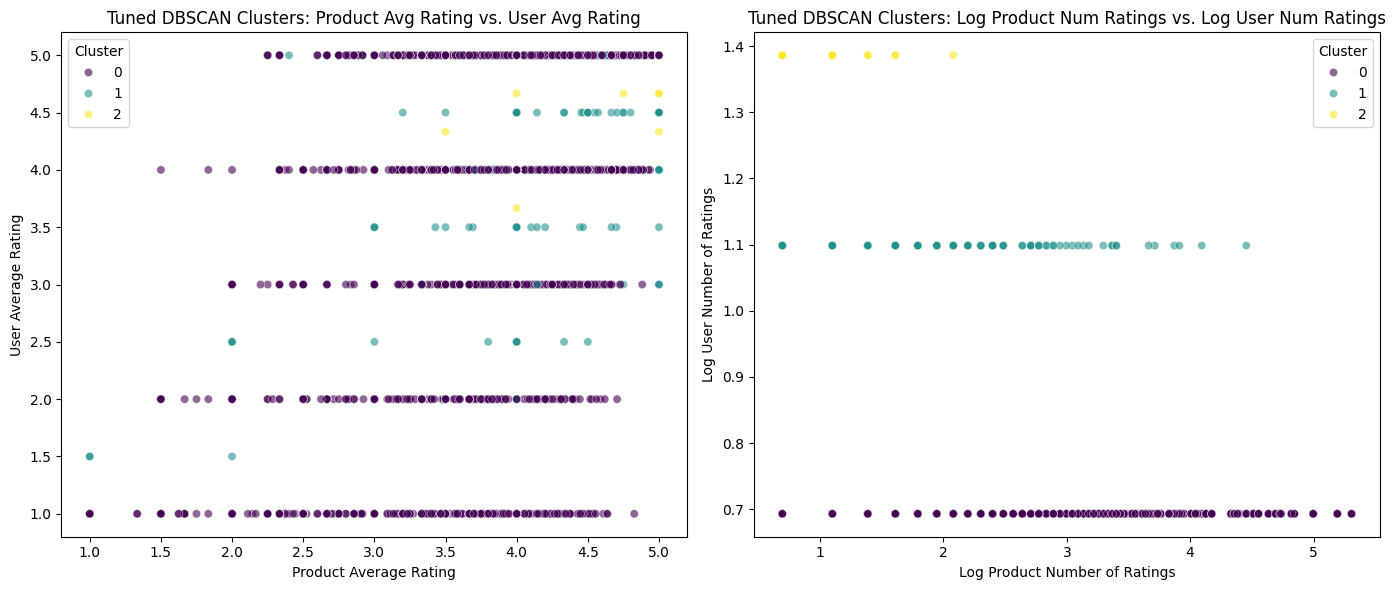

In [ ]:
plt.figure(figsize=(14, 6))

# Filter out noise points (cluster label -1) for visualization
plotting_df_tuned = sampled_df[sampled_df['dbscan_cluster_tuned'] != -1]

plt.subplot(1, 2, 1) # First subplot
sns.scatterplot(x='product_avg_rating', y='user_avg_rating', hue='dbscan_cluster_tuned', data=plotting_df_tuned, palette='viridis', alpha=0.6)
plt.title('Tuned DBSCAN Clusters: Product Avg Rating vs. User Avg Rating')
plt.xlabel('Product Average Rating')
plt.ylabel('User Average Rating')
plt.legend(title='Cluster')

plt.subplot(1, 2, 2) # Second subplot
sns.scatterplot(x='product_num_ratings_log', y='user_num_ratings_log', hue='dbscan_cluster_tuned', data=plotting_df_tuned, palette='viridis', alpha=0.6)
plt.title('Tuned DBSCAN Clusters: Log Product Num Ratings vs. Log User Num Ratings')
plt.xlabel('Log Product Number of Ratings')
plt.ylabel('Log User Number of Ratings')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

tuned DBSCAN has highest silhouette score compared to other two models

# **Recommendation System**

# **Item-Based Collaborative Filtering Recommendations:**

In [ ]:
product_id_to_index = {product_id: i for i, product_id in enumerate(productid_cat.cat.categories)}
product_id_to_index

{'0594481813': 0,
 '0972683275': 1,
 '0983947600': 2,
 '1400501466': 3,
 '1400501776': 4,
 '1400532620': 5,
 '1400532655': 6,
 '140053271X': 7,
 '1400532736': 8,
 '1400698987': 9,
 '1615527656': 10,
 '1615543570': 11,
 '161685572X': 12,
 '1934931403': 13,
 '3744295508': 14,
 '6301977173': 15,
 '7214047977': 16,
 '7799813393': 17,
 '7807284382': 18,
 '8866139874': 19,
 '9573212900': 20,
 '9573212919': 21,
 '9574423271': 22,
 '9575871979': 23,
 '9625993428': 24,
 '9888002198': 25,
 '9966210784': 26,
 '9966284826': 27,
 '9966338926': 28,
 '9966569863': 29,
 '9966696717': 30,
 '9983722011': 31,
 '9983750341': 32,
 '998383054X': 33,
 '9983891212': 34,
 '9984971805': 35,
 '998554174X': 36,
 '9985622456': 37,
 '9985673379': 38,
 '9985686764': 39,
 '9989494991': 40,
 'B000001OM5': 41,
 'B000001OM8': 42,
 'B000001OMI': 43,
 'B000001OMZ': 44,
 'B000001ON0': 45,
 'B000001ON6': 46,
 'B00000DM9W': 47,
 'B00000IGBF': 48,
 'B00000J061': 49,
 'B00000J08Q': 50,
 'B00000J0BM': 51,
 'B00000J0D2': 52,
 'B

In [ ]:
index_to_product_id = {i: product_id for i, product_id in enumerate(productid_cat.cat.categories)}
index_to_product_id

{0: '0594481813',
 1: '0972683275',
 2: '0983947600',
 3: '1400501466',
 4: '1400501776',
 5: '1400532620',
 6: '1400532655',
 7: '140053271X',
 8: '1400532736',
 9: '1400698987',
 10: '1615527656',
 11: '1615543570',
 12: '161685572X',
 13: '1934931403',
 14: '3744295508',
 15: '6301977173',
 16: '7214047977',
 17: '7799813393',
 18: '7807284382',
 19: '8866139874',
 20: '9573212900',
 21: '9573212919',
 22: '9574423271',
 23: '9575871979',
 24: '9625993428',
 25: '9888002198',
 26: '9966210784',
 27: '9966284826',
 28: '9966338926',
 29: '9966569863',
 30: '9966696717',
 31: '9983722011',
 32: '9983750341',
 33: '998383054X',
 34: '9983891212',
 35: '9984971805',
 36: '998554174X',
 37: '9985622456',
 38: '9985673379',
 39: '9985686764',
 40: '9989494991',
 41: 'B000001OM5',
 42: 'B000001OM8',
 43: 'B000001OMI',
 44: 'B000001OMZ',
 45: 'B000001ON0',
 46: 'B000001ON6',
 47: 'B00000DM9W',
 48: 'B00000IGBF',
 49: 'B00000J061',
 50: 'B00000J08Q',
 51: 'B00000J0BM',
 52: 'B00000J0D2',
 53

In [ ]:
def get_item_recommendations(target_product_id, item_similarity_matrix, k=5, similarity_threshold=0.0):
    """
    Generates item-based recommendations for a target product.

    Args:
        target_product_id (str): The ID of the product for which to find similar items.
        item_similarity_matrix (np.ndarray): The precomputed item-item cosine similarity matrix.
        k (int): The number of top similar products to recommend.
        similarity_threshold (float): Minimum similarity score for a product to be considered.

    Returns:
        list: A list of recommended product IDs.
    """
    #print(f"Target Product ID: {target_product_id}")
    if target_product_id not in product_id_to_index:
        print(f"Product ID '{target_product_id}' not found.")
        return []
    target_product_index = product_id_to_index[target_product_id]
    #print(f"Target Product Index: {target_product_index}")
    similar_scores = item_similarity_matrix[target_product_index]
    #print(f"Similar Scores: {similar_scores}")
    similar_products_series = pd.Series(similar_scores, index=productid_cat.cat.categories)
    #print(f"Similar Products Series: {similar_products_series}")
    recommended_products = similar_products_series.drop(target_product_id).sort_values(ascending=False)
    #print(f"Recommended Products: {recommended_products}")
    recommended_products = recommended_products[recommended_products >= similarity_threshold]
    #print(f"Recommended Products >= Similarity Threshold: {recommended_products}")

    return recommended_products.head(k).index.tolist()

In [ ]:
example_product_id = input('Enter a product ID: ')

Enter a product ID: B0035ERKYW


In [ ]:
thresholds = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]

In [ ]:
for threshold in thresholds:

  print(f"\n--- Threshold: {threshold} ---")
  recommendations = get_item_recommendations(
        example_product_id,
        item_similarity,
        k=100, # Get more recommendations to see the effect of threshold clearly
        similarity_threshold=threshold
    )

  if recommendations:
        print(f"Number of recommendations: {len(recommendations)}")
        for i, product in enumerate(recommendations[:10]): # Print top 10 for brevity
            print(f"{i+1}. {product}")
        if len(recommendations) > 10:
            print(f"... and {len(recommendations) - 10} more.")
  else:
        print("No recommendations found above this threshold.")


--- Threshold: 0.0 ---
Number of recommendations: 100
1. B00L2EZ60C
2. 0594481813
3. 0972683275
4. 0983947600
5. 1400501466
6. 1400501776
7. 1400532620
8. 1400532655
9. 140053271X
10. 1400532736
... and 90 more.

--- Threshold: 0.1 ---
No recommendations found above this threshold.

--- Threshold: 0.3 ---
No recommendations found above this threshold.

--- Threshold: 0.5 ---
No recommendations found above this threshold.

--- Threshold: 0.7 ---
No recommendations found above this threshold.

--- Threshold: 0.9 ---
No recommendations found above this threshold.


In [ ]:
# Check the number of ratings for the current example_product_id
num_ratings_current_product = rating_features_df_cleaned[rating_features_df_cleaned['productid'] == example_product_id].shape[0]
print(f"Number of ratings for '{example_product_id}': {num_ratings_current_product}")

if num_ratings_current_product <= 1:
    print(f"Product '{example_product_id}' has too few ratings ({num_ratings_current_product}) to compute meaningful similarities. Switching to a more popular product for demonstration.")
    # Use a popular product for demonstration
    example_product_id = 'B0074BW614' # One of the top 10 most frequent product IDs
    print(f"New example Product ID: {example_product_id}")
else:
    print(f"Product '{example_product_id}' has {num_ratings_current_product} ratings. Continuing with this product.")

# The rest of the loop for recommendations will be executed next to ensure it uses the (potentially updated) example_product_id


Number of ratings for 'B0035ERKYW': 21
Product 'B0035ERKYW' has 21 ratings. Continuing with this product.


# **Function to Predict User Rating for a Product**

In [ ]:
def predict_rating_item_based(user_id, product_id, item_similarity_matrix,
                               item_user_matrix, product_id_to_index, user_id_to_index):

    #print("-----------------------------------------------------------")
    #print(f"User ID: {user_id}")
    #print(f"Product ID: {product_id}")
    #print(f"Item Similarity Matrix : {item_similarity_matrix}")
    #print(f"Item similarity Matrix shape: {item_similarity_matrix.shape}")
    #print(f"Item User Matrix : {item_user_matrix}")
    #print(f"Item user Matrix shape: {item_user_matrix.shape}")
    #print(f"Product ID to Index: {product_id_to_index}")
    #print(f"User ID to Index: {user_id_to_index}")
    #print("-----------------------------------------------------------")

    if product_id not in product_id_to_index or user_id not in user_id_to_index:
        print(f"Product ID '{product_id}' or User ID '{user_id}' not found.")
        return None

    target_product_idx = product_id_to_index[product_id]
    #print("-----------------------------------------------------------")
    #print(f"target_product_idx: {target_product_idx}")
    #print("-----------------------------------------------------------")

    user_index = user_id_to_index[user_id]
    #print("-----------------------------------------------------------")
    #print(f"user_index: {user_index}")
    #print("-----------------------------------------------------------")

    # Get similarity scores for the target product
    similarities = item_similarity_matrix[target_product_idx]
    #print("-----------------------------------------------------------")
    #print(f"similarities: {similarities}")
    #print("-----------------------------------------------------------")


    # Get products rated by this user from the sparse matrix
    user_rated_indices = item_user_matrix[:, user_index].nonzero()[0]
    #print("-----------------------------------------------------------")
    #print(f"user_rated_indices: {user_rated_indices}")
    #print("-----------------------------------------------------------")


    if len(user_rated_indices) == 0:
        #print(f"User '{user_id}' has no rated products in the matrix.")
        return None

    user_ratings = item_user_matrix[user_rated_indices, user_index].toarray().flatten()
    #print("-----------------------------------------------------------")
    #print(f"user_ratings: {user_ratings}")
    #print("-----------------------------------------------------------")

    relevant_similarities = similarities[user_rated_indices]
    #print("-----------------------------------------------------------")
    #print(f"relevant_similarities: {relevant_similarities}")
    #print("-----------------------------------------------------------")


    # Exclude the target product itself from the calculation
    mask = (user_rated_indices != target_product_idx) & (relevant_similarities > 0)
    #print("-----------------------------------------------------------")
    #print(f"mask: {mask}")
    #print("-----------------------------------------------------------")

    pos_sim = relevant_similarities[mask]
    #print("-----------------------------------------------------------")
    #print(f"pos_sim: {pos_sim}")
    #print("-----------------------------------------------------------")

    pos_ratings = user_ratings[mask]
    #print("-----------------------------------------------------------")
    #print(f"pos_ratings: {pos_ratings}")
    #print("-----------------------------------------------------------")


    if len(pos_sim) == 0 or np.sum(pos_sim) == 0:
        user_col = item_user_matrix[:, user_index]
        #print("-----------------------------------------------------------")
        #print(f"user_col: {user_col}")
        #print("-----------------------------------------------------------")

        user_avg = user_col.data.mean() if user_col.nnz > 0 else None
        #print("-----------------------------------------------------------")
        #print(f"user_avg: {user_avg}")
        #print("----------------------------------------------------------")

        return float(user_avg) if user_avg is not None else None


    predicted = np.dot(pos_sim, pos_ratings) / np.sum(pos_sim)
    #print("-----------------------------------------------------------")
    #print(f"predicted: {predicted}")
    #print("-----------------------------------------------------------")

    return round(predicted, 2)

#**Predicting a Rating**

In [ ]:
import numpy as np

# To use this function, we need a user_id_to_index mapping
user_id_to_index = {user_id: i for i, user_id in enumerate(userid_cat.cat.categories)}

# Example: Pick an existing user and a product they haven't rated
some_user_id = np.random.choice(rating_features_df_cleaned['userid'].unique())
print(f"Example User ID: {some_user_id}")

user_rated_products = rating_features_df_cleaned[rating_features_df_cleaned['userid'] == some_user_id]['productid'].unique()
#print("-----------------------------------------------------------")
#print(f"User '{some_user_id}' has rated {len(user_rated_products)} products:")
#print("-----------------------------------------------------------")
all_product_ids = rating_features_df_cleaned['productid'].unique()
#print("-----------------------------------------------------------")
#print(f"All products in the dataset: {all_product_ids}")
#print(f"All products in the dataset: {len(all_product_ids)}")
#print("-----------------------------------------------------------")
user_rated_set = set(user_rated_products)
#print("-----------------------------------------------------------")
#print(f"User '{some_user_id}' has rated: {user_rated_set}")
#print("-----------------------------------------------------------")
unrated_products_by_user = [pid for pid in all_product_ids if pid not in user_rated_set]
#print("-----------------------------------------------------------")
#print(f"Unrated products by user '{some_user_id}': {unrated_products_by_user}")
#print("-----------------------------------------------------------")
#print(f"Length of unrated products by user: {len(unrated_products_by_user)}")

if unrated_products_by_user:
    product_rating_counts = rating_features_df_cleaned['productid'].value_counts()
    #print("-----------------------------------------------------------")
    #print(f"Product rating counts: {product_rating_counts}")
    #print("-----------------------------------------------------------")
    popular_unrated = [
        pid for pid in unrated_products_by_user
        if product_rating_counts.get(pid, 0) > 5
    ]
    #print("-----------------------------------------------------------")
    #print(f"Popular unrated products: {popular_unrated}")
    #print(f"length of popular unrated products: {len(popular_unrated)}")
    #print("-----------------------------------------------------------")
    target_product_to_predict = popular_unrated[0] if popular_unrated else unrated_products_by_user[0]
    print(f"Target Product ID for prediction: {target_product_to_predict}")

    predicted_rating = predict_rating_item_based(
        some_user_id,
        target_product_to_predict,
        item_similarity,
        item_user_matrix,
        product_id_to_index,
        user_id_to_index
    )

    if predicted_rating is not None:
        print(f"Predicted rating for User '{some_user_id}' on Product '{target_product_to_predict}': {predicted_rating:.2f}")
    else:
        fallback = rating_features_df_cleaned[rating_features_df_cleaned['productid'] == target_product_to_predict]['rating'].mean()
        if not np.isnan(fallback):
            print(f"Cold start — no similar items found. Product average rating: {fallback:.2f}")
        else:
            print("No data available for prediction.")
else:
    print(f"User '{some_user_id}' has rated all products in the dataset.")

Example User ID: A1J1G8JN9DQ2KL
Target Product ID for prediction: B002L6HE9G
Predicted rating for User 'A1J1G8JN9DQ2KL' on Product 'B002L6HE9G': 5.00


# **Evaluation**

Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    rating_features_df_cleaned[['userid', 'productid', 'rating']],
    test_size=0.2,
    random_state=42
)

print(f"Train size: {train_df.shape}")
print(f"Test size: {test_df.shape}")

Train size: (61969, 3)
Test size: (15493, 3)


In [ ]:
train_df.head()

,userid,productid,rating
7844,A1RQHKP3AR1VBR,B001SH2AVQ,4.0
54757,A2K7Y00ZUVSGW6,B002WQTS58,5.0
20265,A1QPHZ5N5Y81N3,B00AA8N89W,3.0
34535,A3SC3HNBE0M854,B00F07KAVM,5.0
69279,A2I2KPNJDQ9SL0,B00429N18S,5.0


In [ ]:
test_df.head()

,userid,productid,rating
60808,A3186S6CU85OAK,B001S0I26K,5.0
63380,ASQJ6C3B0YDWK,B004N85YB0,1.0
56609,A1IUTC98096AV7,B004H1RYCU,1.0
60581,A3QMU6U31VQ638,B0054KIIFU,1.0
26902,A3H9MYVGSV0M2R,B00834SJNA,5.0


Rebuilding sparse matrix on train data only

In [ ]:
train_userid_cat = train_df['userid'].astype('category')
train_userid_cat.head()

,userid
7844,A1RQHKP3AR1VBR
54757,A2K7Y00ZUVSGW6
20265,A1QPHZ5N5Y81N3
34535,A3SC3HNBE0M854
69279,A2I2KPNJDQ9SL0


In [ ]:
train_userid_cat.shape

(61969,)

In [ ]:
train_productid_cat = train_df['productid'].astype('category')
train_productid_cat.head()

,productid
7844,B001SH2AVQ
54757,B002WQTS58
20265,B00AA8N89W
34535,B00F07KAVM
69279,B00429N18S


In [ ]:
train_productid_cat.shape

(61969,)

In [ ]:
train_user_idx = train_userid_cat.cat.codes
train_user_idx.head()

,0
7844,12536
54757,25326
20265,12085
34535,45066
69279,24349


In [ ]:
train_user_idx.shape

(61969,)

In [ ]:
train_product_idx = train_productid_cat.cat.codes
train_product_idx.head()

,0
7844,10479
54757,13138
20265,29270
34535,32652
69279,16864


In [ ]:
train_product_idx.shape

(61969,)

In [ ]:
train_sparse_matrix = csr_matrix(
    (train_df['rating'], (train_user_idx, train_product_idx))
)
train_sparse_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 61969 stored elements and shape (61129, 34044)>

In [ ]:
train_item_user_matrix = train_sparse_matrix.T
train_item_user_matrix

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 61969 stored elements and shape (34044, 61129)>

In [ ]:
train_item_similarity = cosine_similarity(train_item_user_matrix)
train_item_similarity

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [ ]:
train_product_id_to_index = {pid: i for i, pid in enumerate(train_productid_cat.cat.categories)}
train_product_id_to_index

{'0972683275': 0,
 '0983947600': 1,
 '1400501466': 2,
 '1400501776': 3,
 '1400532620': 4,
 '1400532655': 5,
 '140053271X': 6,
 '1400698987': 7,
 '1615527656': 8,
 '1615543570': 9,
 '161685572X': 10,
 '1934931403': 11,
 '3744295508': 12,
 '6301977173': 13,
 '7214047977': 14,
 '7799813393': 15,
 '7807284382': 16,
 '8866139874': 17,
 '9573212919': 18,
 '9574423271': 19,
 '9575871979': 20,
 '9888002198': 21,
 '9966210784': 22,
 '9966284826': 23,
 '9966338926': 24,
 '9966569863': 25,
 '9983722011': 26,
 '9983750341': 27,
 '998383054X': 28,
 '9983891212': 29,
 '9984971805': 30,
 '9985622456': 31,
 '9985673379': 32,
 '9985686764': 33,
 '9989494991': 34,
 'B000001OM5': 35,
 'B000001OM8': 36,
 'B000001OMI': 37,
 'B000001OMZ': 38,
 'B000001ON0': 39,
 'B000001ON6': 40,
 'B00000DM9W': 41,
 'B00000IGBF': 42,
 'B00000J061': 43,
 'B00000J08Q': 44,
 'B00000J0BM': 45,
 'B00000J0D2': 46,
 'B00000J0D5': 47,
 'B00000J1F3': 48,
 'B00000J1P3': 49,
 'B00000J1QN': 50,
 'B00000J1QZ': 51,
 'B00000J1SC': 52,
 'B

In [ ]:
train_user_id_to_index = {uid: i for i, uid in enumerate(train_userid_cat.cat.categories)}
train_user_id_to_index

{'A000063614T1OE0BUSKUT': 0,
 'A0009478CBXKUCALUC7U': 1,
 'A00101847G3FJTWYGNQA': 2,
 'A00229361XSNMXZ0NHCP0': 3,
 'A00261423251DFHHYVST9': 4,
 'A00328341ID176U2B6RZR': 5,
 'A003734036BYKEBX7UQCZ': 6,
 'A004818027168B4NOA0VS': 7,
 'A00814791Q799HIECQO17': 8,
 'A00922453KLZV2N958PWU': 9,
 'A01044891E81FG2U1NYIL': 10,
 'A0110255Y4ER0RTKEKXS': 11,
 'A01264653E1KJ2GPD8BHN': 12,
 'A01682761RQSOIBP1TBDQ': 13,
 'A01908602S6VC52FKCBA': 14,
 'A01919943HHNPNFJ6WM7U': 15,
 'A02644021OQ11LJQ0KBY0': 16,
 'A02712303HM5RXRLNJUB7': 17,
 'A02713881187LF65WAIQA': 18,
 'A03148423JWGDJNCUIHYF': 19,
 'A034385579DL8F5RC8EE': 20,
 'A03454033TFQ6QT2XBBO3': 21,
 'A0354675WC0G3HKDGAHW': 22,
 'A036040922RLTEL1GK62Y': 23,
 'A0376615V71DIP2WFF6M': 24,
 'A03889472EE5BD6B5IRVB': 25,
 'A042274212BJJVOBS4Q85': 26,
 'A042567831J60IZLE015Z': 27,
 'A04347983EPP67KR7LTS7': 28,
 'A04494961P2WLVB6C85T3': 29,
 'A04871291DNG2J5M3QC41': 30,
 'A0498079L5Z4YA0JYG18': 31,
 'A05034371WRDF5YA1BY9M': 32,
 'A05038873PFB1YB6XYNNG': 33

In [ ]:
print("Train sparse matrix shape:", train_sparse_matrix.shape)

Train sparse matrix shape: (61129, 34044)


Predicting on test set & evaluate

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

actuals = []
predictions = []

filtered_test = test_df[
    test_df['userid'].isin(train_user_id_to_index.keys()) &
    test_df['productid'].isin(train_product_id_to_index.keys())
]
test_sample = filtered_test.sample(min(500, len(filtered_test)), random_state=42)
print(f"Valid test samples: {len(test_sample)}")

for _, row in test_sample.iterrows():
    uid = row['userid']
    pid = row['productid']
    actual = row['rating']

    pred = predict_rating_item_based(
        uid, pid,
        train_item_similarity,
        train_item_user_matrix,
        train_product_id_to_index,
        train_user_id_to_index
    )

    if pred is not None:
        actuals.append(actual)
        predictions.append(pred)

print(f"Predictions made: {len(predictions)} out of 500")
mae  = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

Valid test samples: 226
Predictions made: 226 out of 500
MAE  : 0.4690
RMSE : 0.8348


In [ ]:
most_frequent_rating = rating_features_df_cleaned['rating'].mode()[0]
print(f"The most frequent rating in the entire dataset (rating_features_df_cleaned) is: {most_frequent_rating}")
print(f"This suggests that a threshold of {most_frequent_rating} or higher for 'relevant/liked' items could align with the most common positive feedback.")

# You can also see the full distribution:
# print("\nRating distribution:")
# print(rating_features_df_cleaned['rating'].value_counts().sort_index(ascending=False))

The most frequent rating in the entire dataset (rating_features_df_cleaned) is: 5.0
This suggests that a threshold of 5.0 or higher for 'relevant/liked' items could align with the most common positive feedback.


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Treat rating >= 5.0 as "relevant/liked"
threshold = most_frequent_rating

actual_binary    = [1 if a >= threshold else 0 for a in actuals]
predicted_binary = [1 if p >= threshold else 0 for p in predictions]

precision = precision_score(actual_binary, predicted_binary)
recall    = recall_score(actual_binary, predicted_binary)
f1        = f1_score(actual_binary, predicted_binary)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Precision : 0.8067
Recall    : 0.7516
F1-Score  : 0.7781


In [ ]:
print("=== Performance Analysis ===")
print(f"MAE  {mae:.4f}  — average error in predicted rating")
print(f"RMSE {rmse:.4f}  — penalizes large prediction errors more")
print(f"Precision {precision:.4f} — of predicted 'liked', how many actually liked")
print(f"Recall    {recall:.4f} — of actually liked, how many did we catch")
print(f"F1        {f1:.4f} — balance of precision and recall")

print("\n=== Areas of Improvement ===")
print("1. Cold Start : users/products with few ratings get None predictions")
print("2. Sparsity   : matrix is highly sparse, reducing similarity quality")
print("3. Try SVD / Matrix Factorization for better predictions")
print("4. Tune similarity threshold in get_item_recommendations")

=== Performance Analysis ===
MAE  0.4690  — average error in predicted rating
RMSE 0.8348  — penalizes large prediction errors more
Precision 0.8067 — of predicted 'liked', how many actually liked
Recall    0.7516 — of actually liked, how many did we catch
F1        0.7781 — balance of precision and recall

=== Areas of Improvement ===
1. Cold Start : users/products with few ratings get None predictions
2. Sparsity   : matrix is highly sparse, reducing similarity quality
3. Try SVD / Matrix Factorization for better predictions
4. Tune similarity threshold in get_item_recommendations


In [ ]:
print(f"Total predictions         : {len(predictions)}")
print(f"Predicted as liked (>=4): {sum(predicted_binary)}")
print(f"Actually liked (>=4)    : {sum(actual_binary)}")
print(f"Average predicted rating  : {np.mean(predictions):.2f}")
print(f"Average actual rating     : {np.mean(actuals):.2f}")
print(f"\nPrediction value counts:")
print(pd.Series(predictions).describe())

Total predictions         : 226
Predicted as liked (>=4): 150
Actually liked (>=4)    : 161
Average predicted rating  : 4.54
Average actual rating     : 4.60

Prediction value counts:
count    226.000000
mean       4.544248
std        0.752942
min        1.000000
25%        4.000000
50%        5.000000
75%        5.000000
max        5.000000
dtype: float64


# **Deployment**

In [ ]:
import pickle
from scipy.sparse import save_npz

 Saving everything the Streamlit app will need

In [ ]:
sampled_df_trimmed = sampled_df[['userid', 'productid',
                                  'product_avg_rating', 'user_avg_rating',
                                  'product_num_ratings_log', 'user_num_ratings_log',
                                  'dbscan_cluster_tuned']].copy()

In [ ]:
save_npz('train_item_user_matrix.npz', train_item_user_matrix)

In [ ]:
artifacts = {
    'product_id_to_index':     product_id_to_index,
    'index_to_product_id':     index_to_product_id,
    'user_id_to_index':        user_id_to_index,
    'scaler':                  scaler,
    'sampled_df':              sampled_df_trimmed,  # we are using sampled_df_trimmed because for whole data it's crashing because of item_similarity is a dense numpy array of shape ~(40K × 40K) = ~12.8 billion floats — that alone is around 12GB
    'features_for_clustering': features_for_clustering,
}

In [ ]:
with open('recommendation_artifacts.pkl', 'wb') as f:      #recommendation_artifacts.pkl is file name
    pickle.dump(artifacts, f)                              # wb is binary write mode


print("✅ Done!")

✅ Done!


In [ ]:
import os
print("pkl size :", round(os.path.getsize('recommendation_artifacts.pkl') / 1024**2, 2), "MB")
print("npz size :", round(os.path.getsize('train_item_user_matrix.npz') / 1024**2, 2), "MB")

pkl size : 5.75 MB
npz size : 0.26 MB


 Save everything the Streamlit app will need

In [ ]:
artifacts = {
    # Item-item similarity (full dataset)
    #'item_similarity': item_similarity,

    # Mappings
    'product_id_to_index': product_id_to_index,
    'index_to_product_id': index_to_product_id,
    'user_id_to_index': user_id_to_index,

    # DBSCAN tuned model + scaler + cluster labels on sampled data
    'dbscan_tuned': dbscan_tuned,
    'scaler': scaler,

    # The sampled_df with dbscan_cluster_tuned column
    'sampled_df': sampled_df[['userid', 'productid', 'product_avg_rating',
                               'user_avg_rating', 'product_num_ratings_log',
                               'user_num_ratings_log', 'dbscan_cluster_tuned']],

    # Features list (needed to scale new inputs)
    'features_for_clustering': ['product_avg_rating', 'user_avg_rating',
                                 'product_num_ratings_log', 'user_num_ratings_log'],

}

In [ ]:
from scipy.sparse import save_npz

In [ ]:
with open('recommendation_artifacts.pkl', 'wb') as f:  #recommendation_artifacts.pkl is file name
    pickle.dump(artifacts, f)                          # wb is binary write mode